# Response time, gain & effect-duration for `03LIC_1071.PV` — rebuilt on 30-sec data

**What changed and why.** The earlier analysis (minute-wise data, a fixed-horizon "gain over 30 min") is rebuilt from scratch on **30-second history**, because (a) SMEs flagged the response times as too large and (b) a single fixed-horizon gain is the wrong quantity for this tag.

**Key idea — `03LIC_1071` is an *integrating* level.** Think of a bathtub: the valve (`.OP`) sets a **flow**, and the level (`.PV`) is the running total of net flow. A valve step does not move the level to a new steady value — it changes the **rate** at which the level moves, and the level keeps drifting until something else changes. Consequences:

- There is **no single steady-state gain** (level % per unit OP); the level change depends entirely on how long you wait. So we model the **rate** `d(PV)/dt` (a stable quantity) and report an **integrating gain** = level %/min per unit of handle, plus the **effect-vs-time** curve.
- The valve's **onset** (when the level *starts* moving) is near-instant, sub-minute — matching the SME. The older "4–6 min" measured when the *accumulated* change cleared the noise, which is a detection time, not a dead time. We report onset / detectable / actionable times separately.

**Trust model.** `03LIC_1071` is a base-layer DCS loop and is **not** in the vendor APC gain matrix, so there is no vendor number to copy for it. We first **validate our estimator against the vendor gains on other tag pairs we can observe**, then apply the validated method to 1071.

**Plan:** (0) data foundation → (1) validate on vendor anchors → (2) screen all `.OP` tags → (3) response times → (4) integrating gain, effect-over-time & persistence → (5) synthesis.

> Data: `DATA/PV-OP_data/consolidated_30sec_data/all_tags_30sec.parquet` — 2021-01-18 → 2025-06-28, 30-sec cadence, 16 controllable `.OP` tags. Env: `adnoc`.


## Alignment with the generalised framework — what changed & why

The reusable engine now lives in **`EXPERIMENTS/gain_response_framework.ipynb`**. This notebook is the **1071 deep-dive / reference derivation** and the **working notebook for the next steps**. The decisions crystallised in the framework and adopted here (brief — no re-proof):

1. **Mode-aware self-valve = the RATE method, not the isolated-step method.** The target's own valve is read on **open-loop (MANUAL)** data by regressing the level *rate* on the OP level (de-confounded by feed + supplier). This **supersedes** the earlier "isolated ~14 manual steps" estimate (too few clean steps → order-of-magnitude uncertainty). Part 14, panel B shows *why* the naive level-difference gain is sign-flipped by reverse causation, and the rate method is not.
2. **Horizon-sweep auto-classifier.** The shape of `g(H)` labels the dynamics: **plateau → self-regulating** (fit `K, tau, theta`), **linear ramp → integrating**, **rise-then-decay → closed-loop rejection**. Visualised in Part 14.
3. **Default regime = the 5-95%ile steady band (`within_band`).** It recovers the vendor magnitude for well-excited exogenous paths (`feed -> 1141A` ~0.97-1.03x). This **replaced** the earlier narrow "steady" band that had **zero** usable 60-min windows.
4. **Confidence is sign-FIRST**, then R2 for magnitude, with a **`directional`** tier for real-but-weak levers (honest about the self valve, whose sign is solid but magnitude uncertain).
5. **Response timing streamlined** to two measurable clocks — **dead time** and **tau** → `wait / settle / next_action`. The earlier three-clock "onset / detectable / actionable" split was collapsed.
6. **Vendor validation moved to the framework and expanded to 26 pairs**, run **first** (validate the method) before deriving 1071. Parts 1 & 9 here keep the original 1071-area anchors as the reference; the full 26-pair table (all-data vs in-band) is `RESULTS/gain_response_framework/vendor_validation_1min.xlsx`.

> Everything below (Parts 0-13) is the original derivation, kept intact as the audit trail. Part 14 adds the shape/`tau` visualisation; Part 15 sets up the next steps.


In [1]:
# ============================================================================
# PART 0 — Data foundation
# Load the 30-sec history, put it on a strict 30-sec grid, and report coverage.
# ============================================================================
import numpy as np
import pandas as pd

DATA     = '/home/h604827/ControlActions/DATA'
PARQUET  = f'{DATA}/PV-OP_data/consolidated_30sec_data/all_tags_30sec.parquet'
EVENTS   = f'{DATA}/combined_events/03LIC_1071_PVLO_PVHI_combined_events.parquet'
TRIPS    = f'{DATA}/Final_List_Trip_Duration.csv'
GAIN_CSV = f'{DATA}/Gain Data 12Mar26(Sheet1).csv'

TARGET    = '03LIC_1071.PV'     # the alarm level
TARGET_OP = '03LIC_1071.OP'     # its control valve
FEED      = '02FI_1000.PV'      # total feed (dominant exogenous disturbance)
DT_MIN    = 0.5                 # one 30-sec sample = 0.5 minutes

# ---- load, de-dup, strict 30-sec grid -------------------------------------
raw = pd.read_parquet(PARQUET)
raw['TimeStamp'] = pd.to_datetime(raw['TimeStamp'])
raw = (raw.dropna(subset=['TimeStamp'])
          .drop_duplicates('TimeStamp')
          .set_index('TimeStamp').sort_index())
ts = raw.asfreq('30s')          # any missing 30-sec slot -> NaN (gaps never bridged)

op_tags = sorted(c for c in ts.columns if c.endswith('.OP'))
pv_tags = sorted(c for c in ts.columns if c.endswith('.PV'))
dead    = [c for c in ts.columns if ts[c].isna().all()]   # 100%-NaN tags

print(f'Loaded {ts.shape[0]:,} rows x {ts.shape[1]} cols on a strict 30-sec grid')
print(f'Range : {ts.index.min()}  ->  {ts.index.max()}')
print(f'OP tags ({len(op_tags)}): {[t[:-3] for t in op_tags]}')
print(f'Target {TARGET} present: {TARGET in ts.columns} | feed {FEED} present: {FEED in ts.columns}')
print(f'DEAD tags (100% NaN, excluded from modelling): {dead}')


Loaded 4,670,040 rows x 44 cols on a strict 30-sec grid
Range : 2021-01-18 12:30:00  ->  2025-06-28 01:29:30
OP tags (16): ['03FIC_1085', '03FIC_3415', '03FIC_3435', '03LIC_1016', '03LIC_1071', '03LIC_1085', '03LIC_1094', '03LIC_1097', '03LIC_3178', '03PIC_1013', '03PIC_1068', '03PIC_1104', '03PIC_3131', '03TIC_1092', '03TIC_1142', '03TIC_1145']
Target 03LIC_1071.PV present: True | feed 02FI_1000.PV present: True
DEAD tags (100% NaN, excluded from modelling): ['03TI_1081.PV', '03TI_1901.PV']


In [2]:
# ---- trip filter: NaN-out plant trip / shutdown windows -------------------
# Final_List_Trip_Duration.csv: 'Stop Date' = unit tripped (window start),
# 'Start Date' = unit restarted (window end). We blank [Stop Date, Start Date].
trips = pd.read_csv(TRIPS)
trips['Stop Date']  = pd.to_datetime(trips['Stop Date'],  errors='coerce')
trips['Start Date'] = pd.to_datetime(trips['Start Date'], errors='coerce')
trip_win = (trips.rename(columns={'Stop Date': 'beg', 'Start Date': 'end'})[['beg', 'end']]
                 .dropna())
trip_win = trip_win[trip_win['end'] > trip_win['beg']].sort_values('beg')

idx = ts.index.values
mask_trip = np.zeros(len(ts), dtype=bool)
for b, e in trip_win.itertuples(index=False):
    mask_trip |= (idx >= np.datetime64(b)) & (idx <= np.datetime64(e))

ts.loc[mask_trip, :] = np.nan
print(f'Trip windows applied      : {len(trip_win)}')
print(f'30-sec rows inside trips  : {mask_trip.sum():,} ({100*mask_trip.mean():.1f}%) -> set NaN')
print(f'{TARGET} usable after trip : {ts[TARGET].notna().sum():,} '
      f'({100*ts[TARGET].notna().mean():.1f}%)')


Trip windows applied      : 104
30-sec rows inside trips  : 192,446 (4.1%) -> set NaN
03LIC_1071.PV usable after trip : 3,448,335 (73.8%)


In [3]:
# ---- integrating-rate target: smoothed d(1071.PV)/dt in level%/min ---------
# 1071 is an INTEGRATING level, so we model the RATE of change (a stable number)
# rather than a fixed-horizon level change (horizon-dependent = the old ambiguity).
# Light ~2-min smoothing before a centred difference tames 30-sec sensor noise.
pv        = ts[TARGET]
pv_smooth = pv.rolling(5, center=True, min_periods=4).mean()           # ~2-min smoother
rate      = (pv_smooth.shift(-1) - pv_smooth.shift(1)) / (2 * DT_MIN)  # level %/min
rate[mask_trip] = np.nan
ts['RATE_1071'] = rate

v = rate.dropna()
print(f'd(1071.PV)/dt (level%/min): n = {len(v):,}')
print(v.describe(percentiles=[.01, .05, .5, .95, .99]).round(4).to_string())


d(1071.PV)/dt (level%/min): n = 3,448,139
count    3.448139e+06
mean     2.000000e-04
std      8.308000e-01
min     -4.175910e+01
1%      -2.276700e+00
5%      -1.156800e+00
50%     -0.000000e+00
95%      1.143000e+00
99%      2.249600e+00
max      4.175860e+01


## Part 1 — Validate against the vendor APC gains (small exact overlap + the confirmed `1141A` fuzzy pressure)

The vendor matrix is **ΔPV per ΔOP** (rows = OP/handle, cols = PV). `03LIC_1071` isn't in it, so we validate the *method* on other pairs.

**Exact tag overlap** with our 30-sec data gives two live pairs: feed → `03TIC_1145` (+0.679) and `03FIC_3435.OP` → feed `02FI_1000` (+0.0066). The remaining exact pairs land on the dead `03TI_1081`.

**Fuzzy matching** (same instrument *number*, different type letters PIC vs PI) adds the **`1141A` pressure**: the vendor's `03PIC_1141A` (pressure *controller*) vs our `03PI_1141A` (pressure *indicator* at the same tag number). **This identity is SME-confirmed**, so both `1141A` anchors are treated as solid — this is the one place the fuzzy match matters, and it is settled here.

| our MV → our CV | Vendor gain | Match |
|---|---|---|
| feed `02FI_1000` → `03TIC_1145` | +0.679 | exact (live) |
| `03FIC_3435.OP` → feed `02FI_1000` | +0.0066 | exact (live) |
| `03PIC_1013.OP` → `03PI_1141A` | −11.24 | fuzzy (confirmed) |
| feed `02FI_1000` → `03PI_1141A` | +74.38 | fuzzy (confirmed) |

We **exclude** two number-coincidence fuzzy matches that are physically wrong: vendor `03PIC_1141A` vs our `03FI_1141A` (pressure vs **flow**), and the `03TIC_1092` SP→OP cell (a within-loop coincidence, not a process gain).

**Estimator:** a handle moves almost continuously, so a clean step test rarely exists. We estimate a steady-state gain with a **windowed multivariable difference regression** over a horizon `H`: $\Delta_H\,CV = \sum_i g_i\,\Delta_H\,MV_i + c$, fitting all inputs jointly to de-confound simultaneous moves. When the CV is the feed itself, it is regressed on the handles only (feed cannot be its own input).

In [20]:
# ---- windowed multivariable difference-regression gain estimator ----------
def diff_gain(frame, target, inputs, H_min=60, thin=20, trim=0.001):
    """Steady-state gain of `target` w.r.t. each of `inputs`, via an H-minute
    joint difference regression. Returns (gains dict, n_windows, R2)."""
    H = max(1, int(round(H_min / DT_MIN)))              # horizon in 30-sec samples
    cols = [target] + inputs
    D = pd.DataFrame({c: frame[c].shift(-H) - frame[c] for c in cols})
    D = D.iloc[::thin].dropna()
    if trim:                                            # drop sensor-jump outliers
        lo, hi = D[target].quantile(trim), D[target].quantile(1 - trim)
        D = D[(D[target] >= lo) & (D[target] <= hi)]
    y = D[target].to_numpy()
    X = np.column_stack([D[c].to_numpy() for c in inputs] + [np.ones(len(D))])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    r2 = 1.0 - np.var(y - X @ coef) / np.var(y) if np.var(y) > 0 else np.nan
    return dict(zip(inputs, coef[:-1])), len(D), float(r2)

# Vendor anchors READ FROM 'Gain Data 12Mar26(Sheet1).csv' (row=MV, col=CV = dPV/dOP).
# match='exact' -> our tag name == vendor tag name.
# match='fuzzy' -> same instrument NUMBER, different type letters (vendor 03PIC_1141A
#                  vs our 03PI_1141A). This identity is SME-CONFIRMED, so treated as solid.
# Excluded number-coincidence fuzzies that are physically wrong: 03PIC_1141A vs our
# 03FI_1141A (pressure vs FLOW), and the 03TIC_1092 SP->OP within-loop cell.
VENDOR_ANCHORS = [
    # our_MV,          our_CV,          vendor,   match,   note
    ('02FI_1000.PV',  '03TIC_1145.PV', +0.679,  'exact', 'feed -> 03TIC_1145 (LIVE)'),
    ('03FIC_3435.OP', '02FI_1000.PV',  +0.0066, 'exact', 'handle -> feed (LIVE, real R2)'),
    ('03PIC_1013.OP', '03PI_1141A.PV', -11.235, 'fuzzy', 'vendor 03PIC_1141A = our 03PI_1141A (confirmed)'),
    ('02FI_1000.PV',  '03PI_1141A.PV', +74.377, 'fuzzy', 'vendor 03PIC_1141A = our 03PI_1141A (confirmed)'),
    ('03PIC_1013.OP', '03TI_1081.PV',  -0.087,  'exact', 'CV DEAD'),
    ('02FI_1000.PV',  '03TI_1081.PV',  +2.040,  'exact', 'CV DEAD'),
    ('03TIC_1092.OP', '03TI_1081.PV',  -0.444,  'exact', 'CV DEAD (SP proxy)'),
]
# Inputs (MVs) used to derive each CV's gain. When the CV is the feed itself we
# regress it on the handles only (feed cannot be its own input).
VAL_INPUTS  = ['02FI_1000.PV', '03PIC_1013.OP', '03TIC_1092.OP']
FEED_INPUTS = ['03PIC_1013.OP', '03TIC_1092.OP', '03FIC_3435.OP']
live = [a for a in VENDOR_ANCHORS if a[1] not in dead]
print(f'Vendor anchors: {len(VENDOR_ANCHORS)} | live/testable: {len(live)}  '
      f'(exact live: feed->03TIC_1145, 03FIC_3435->feed; confirmed-fuzzy: 2x 1141A pressure)')

Vendor anchors: 7 | live/testable: 4  (exact live: feed->03TIC_1145, 03FIC_3435->feed; confirmed-fuzzy: 2x 1141A pressure)


In [21]:
# ---- test each LIVE anchor: our derived gain vs the vendor value -----------
rows = []
for cv in sorted({a[1] for a in VENDOR_ANCHORS if a[1] not in dead}):
    inputs = FEED_INPUTS if cv == FEED else VAL_INPUTS     # feed-as-CV -> regress on handles only
    gains, n, r2 = diff_gain(ts, cv, inputs, H_min=60, thin=20)
    for mv, cvx, van, match, note in VENDOR_ANCHORS:
        if cvx != cv or cvx in dead or mv not in gains:
            continue
        der = gains[mv]
        rows.append({'MV': mv, 'CV': cv, 'match': match,
                     'derived': round(der, 3), 'vendor': van,
                     'sign_match': bool(np.sign(der) == np.sign(van)),
                     'ratio': round(der / van, 2), 'R2': round(r2, 3)})
val = pd.DataFrame(rows)
print('VENDOR VALIDATION (live anchors; 1141A fuzzy match is SME-confirmed):')
print(val.to_string(index=False))
print(f"\nSign-match: {val['sign_match'].sum()}/{len(val)}  "
      f"(03FIC_3435->feed is the exact anchor with real R2; feed->03TIC_1145 is uninformative).")
untested = [f'{mv}->{cv} (vendor {v:+.3f})' for mv, cv, v, m, nt in VENDOR_ANCHORS if cv in dead]
print('Could NOT be tested (CV is 100%-NaN dead):', untested)
val

VENDOR VALIDATION (live anchors; 1141A fuzzy match is SME-confirmed):
           MV            CV match  derived   vendor  sign_match  ratio    R2
03FIC_3435.OP  02FI_1000.PV exact    0.033   0.0066        True   5.06 0.156
03PIC_1013.OP 03PI_1141A.PV fuzzy   -7.386 -11.2350        True   0.66 0.383
 02FI_1000.PV 03PI_1141A.PV fuzzy   35.500  74.3770        True   0.48 0.383
 02FI_1000.PV 03TIC_1145.PV exact   -0.311   0.6790       False  -0.46 0.009

Sign-match: 3/4  (03FIC_3435->feed is the exact anchor with real R2; feed->03TIC_1145 is uninformative).
Could NOT be tested (CV is 100%-NaN dead): ['03PIC_1013.OP->03TI_1081.PV (vendor -0.087)', '02FI_1000.PV->03TI_1081.PV (vendor +2.040)', '03TIC_1092.OP->03TI_1081.PV (vendor -0.444)']


,MV,CV,match,derived,vendor,sign_match,ratio,R2
0,03FIC_3435.OP,02FI_1000.PV,exact,0.033,0.0066,True,5.06,0.156
1,03PIC_1013.OP,03PI_1141A.PV,fuzzy,-7.386,-11.2350,True,0.66,0.383
2,02FI_1000.PV,03PI_1141A.PV,fuzzy,35.500,74.3770,True,0.48,0.383
3,02FI_1000.PV,03TIC_1145.PV,exact,-0.311,0.6790,False,-0.46,0.009


### Validation verdict — direction confirmed on the informative anchors

- **`03FIC_3435.OP` → feed (+0.0066):** our data gives **+0.033, R² ≈ 0.16** → **sign-matches**, and this is the one *exact* live anchor with real explanatory power (every other exact pair is dead-CV or R² ≈ 0.01). Magnitude runs ~5× the vendor value — expected: the true effect is tiny and our estimate also absorbs shared plant-throughput movement. Direction is solid.
- **`1141A` pressure anchors:** both **sign-match** — `03PIC_1013.OP` ≈ −7.4 vs −11.24, and feed ≈ +35.5 vs +74.38 — at ~50–66% magnitude (expected, given closed-loop attenuation and the omitted `03HIC_1141` recycle valve).
- **feed → `03TIC_1145` (+0.679):** our data gives ≈ **−0.31, R² ≈ 0.01** → **uninformative**: this temperature's own valve sits shut and it is driven by unmeasured factors, so the pair can neither confirm nor refute (treated as untestable, not a failure).

**Verdict:** of the three anchors that carry information (`03FIC_3435`→feed and the two `1141A` pressures), **all three sign-match** — 3 of 4 testable overall. This is solid support for the method's **direction**; magnitudes differ ~2–5× for the structural reasons above (open-loop vendor gains vs closed-loop routine data, omitted MVs, throughput co-movement). The `03LIC_1071` findings are corroborated by this cross-check *and* by physics + internal consistency + monthwise sign-stability.

## Part 2 — Which `.OP` handles actually move `03LIC_1071`? (data-driven screen)

We rank all 16 handles by their effect on the level. **Static handle *positions* barely predict the instantaneous rate** — the rate is dominated by the feed disturbance and noise, so a contemporaneous level regression gives R² ≈ 0 and even mis-ranks the feed to the bottom. The causal signal lives in **changes**: over a short horizon *h*, how much does the 1071 level move per unit *change* of each handle?

$$\Delta_h\,\text{PV}_{1071}(t) \;=\; \sum_j \beta_j\,\Delta_h\,\text{handle}_j(t) \;+\; c$$

We screen two ways — **single-input** (interpretable) and **joint standardized** (de-confounded) — and **sanity-check that the known driver, feed `02FI_1000`, ranks at the top**. If it doesn't, the screen isn't trustworthy. Handles that both screens agree on go into the deep-dive.

> `03LIC_1071.OP` is the tag's own valve in closed loop, so its coefficient carries reverse causation (the controller moves it *because* the level is moving). It stays in as a control; its self-effect is read separately in Part 3.


In [22]:
# ---- Part 2 modelling frame: how CHANGING a handle changes the level ------
# Static OP *levels* barely predict the rate (R^2 ~ 0, feed mis-ranked). The causal
# signal is in *changes*: over a short horizon h, how much does the 1071 level move
# per unit change of a handle? (Delta_h x(t) = x(t+h) - x(t).)
from sklearn.linear_model import LinearRegression

SCREEN_INPUTS = op_tags + [FEED]
H_SCREEN      = int(round(10 / DT_MIN))          # 10-min horizon (20 samples)

dcols = [TARGET] + SCREEN_INPUTS
D = pd.DataFrame({c: ts[c].shift(-H_SCREEN) - ts[c] for c in dcols}).iloc[::8]
D = D.replace([np.inf, -np.inf], np.nan).dropna()
lo, hi = D[TARGET].quantile(.005), D[TARGET].quantile(.995)   # trim sensor jumps
D = D[(D[TARGET] >= lo) & (D[TARGET] <= hi)]

yD   = D[TARGET].to_numpy()
XD   = D[SCREEN_INPUTS]
XDsd = XD.std().replace(0, 1.0)
XDz  = (XD - XD.mean()) / XDsd
print(f'Change-based screen frame: {len(D):,} rows | horizon = {H_SCREEN*DT_MIN:.0f} min')


Change-based screen frame: 426,577 rows | horizon = 10 min


In [23]:
# ---- single-input: level move per unit handle change over the horizon -----
single = []
for c in SCREEN_INPUTS:
    xc = D[c].to_numpy()
    A = np.column_stack([xc, np.ones_like(xc)])
    (k, b), *_ = np.linalg.lstsq(A, yD, rcond=None)
    r2 = 1 - np.var(yD - A @ [k, b]) / np.var(yD)
    single.append({'handle': c[:-3],
                   'gain_per_unit_chg': round(float(k), 4),
                   'effect_1sigma_lvl': round(float(k * xc.std()), 4),
                   'R2_single': round(float(r2), 4)})
single = pd.DataFrame(single)
single = single.reindex(single['effect_1sigma_lvl'].abs()
                        .sort_values(ascending=False).index).reset_index(drop=True)
print(f'SINGLE-INPUT change screen (1071 level move per 1-sigma handle change over '
      f'{H_SCREEN*DT_MIN:.0f} min):')
print(single.to_string(index=False))


SINGLE-INPUT change screen (1071 level move per 1-sigma handle change over 10 min):
    handle  gain_per_unit_chg  effect_1sigma_lvl  R2_single
03LIC_1071            -2.0381            -2.7865     0.7985
03LIC_1016            -0.5520            -1.2892     0.1709
 02FI_1000            -4.7407            -0.6298     0.0408
03FIC_3435            -0.1291            -0.1538     0.0024
03LIC_3178             0.1155             0.1368     0.0019
03PIC_1013            -0.2189            -0.1353     0.0019
03PIC_1104            -0.2147            -0.0543     0.0003
03FIC_1085             0.0134             0.0336     0.0001
03LIC_1094            -0.0207            -0.0282     0.0001
03PIC_3131             0.0152             0.0242     0.0001
03LIC_1085            -0.0074            -0.0232     0.0001
03PIC_1068            -0.0136            -0.0037     0.0000
03FIC_3415             0.0007             0.0009     0.0000
03TIC_1092             0.0002             0.0005     0.0000
03LIC_1097      

In [24]:
# ---- joint standardized change-regression -> de-confounded importance -----
reg = LinearRegression().fit(XDz.to_numpy(), yD)
joint = pd.DataFrame({'handle': [c[:-3] for c in SCREEN_INPUTS],
                      'std_coef_lvl': np.round(reg.coef_, 4)})
joint = joint.reindex(joint['std_coef_lvl'].abs()
                      .sort_values(ascending=False).index).reset_index(drop=True)
print(f'JOINT standardized change-regression: R2 = {reg.score(XDz.to_numpy(), yD):.3f}')
print('(std_coef = 1071 level move [%] per 1-sigma change of that handle, others held fixed)')
print(joint.to_string(index=False))


JOINT standardized change-regression: R2 = 0.803
(std_coef = 1071 level move [%] per 1-sigma change of that handle, others held fixed)
    handle  std_coef_lvl
03LIC_1071       -2.8562
03LIC_1016        0.1493
03FIC_1085        0.1300
03FIC_3435        0.0898
 02FI_1000       -0.0667
03LIC_1085       -0.0461
03PIC_1104       -0.0383
03LIC_3178        0.0307
03TIC_1092       -0.0175
03PIC_1068        0.0154
03LIC_1094        0.0143
03FIC_3415       -0.0130
03PIC_3131       -0.0063
03LIC_1097        0.0043
03PIC_1013       -0.0016
03TIC_1142        0.0000
03TIC_1145        0.0000


In [25]:
# ---- reconcile the two screens -> deep-dive set ---------------------------
rank = single[['handle', 'effect_1sigma_lvl', 'R2_single']].merge(joint, on='handle')
rank['rank_single'] = rank['effect_1sigma_lvl'].abs().rank(ascending=False).astype(int)
rank['rank_joint']  = rank['std_coef_lvl'].abs().rank(ascending=False).astype(int)
rank['avg_rank']    = (rank['rank_single'] + rank['rank_joint']) / 2
rank = rank.sort_values('avg_rank').reset_index(drop=True)
print('COMBINED RANKING (lower avg_rank = stronger effect on the 1071 level):')
print(rank.to_string(index=False))

feed_rank = int(rank.index[rank['handle'] == '02FI_1000'][0]) + 1
print(f"\nSanity check - feed 02FI_1000 combined position: #{feed_rank} of {len(rank)} "
      f"({'OK, screen trustworthy' if feed_rank <= 3 else 'WARNING: feed not on top'})")

# deep-dive = top movers (data) + the propane-loop handles of interest (available ones)
PROPOSED = ['03LIC_1016', '03LIC_1071', '03PIC_1013', '03TIC_1092', '03TIC_1145']
top      = [h for h in rank.head(6)['handle'] if h != '02FI_1000']
DEEPDIVE = [f'{t}.OP' for t in dict.fromkeys(top + PROPOSED) if f'{t}.OP' in op_tags]
print('Deep-dive handles (top movers + available proposed):', [t[:-3] for t in DEEPDIVE])


COMBINED RANKING (lower avg_rank = stronger effect on the 1071 level):
    handle  effect_1sigma_lvl  R2_single  std_coef_lvl  rank_single  rank_joint  avg_rank
03LIC_1071            -2.7865     0.7985       -2.8562            1           1       1.0
03LIC_1016            -1.2892     0.1709        0.1493            2           2       2.0
 02FI_1000            -0.6298     0.0408       -0.0667            3           5       4.0
03FIC_3435            -0.1538     0.0024        0.0898            4           4       4.0
03FIC_1085             0.0336     0.0001        0.1300            8           3       5.5
03LIC_3178             0.1368     0.0019        0.0307            5           8       6.5
03PIC_1104            -0.0543     0.0003       -0.0383            7           7       7.0
03LIC_1085            -0.0232     0.0001       -0.0461           11           6       8.5
03LIC_1094            -0.0282     0.0001        0.0143            9          11      10.0
03PIC_1013            -0.1353

## Part 3 — Response time: three different clocks

A valve move produces **three distinct times**. For an integrating level:

- **Onset (dead time)** — from the valve move to the level *first* reacting. For the direct `03LIC_1071` valve this is near-instant (the flow changes in seconds), so we expect **sub-minute**.
- **Detectable** — from the move to when the accumulated level change clears the sensor noise. A few minutes (this is what the old "4–6 min" actually measured).
- **Actionable** — from the move to when the level has shifted enough to re-evaluate.

We measure onset with a **step-response overlay**: take discrete `03LIC_1071.OP` steps, align at t=0, baseline the level, and average — separately for **increase** vs **decrease** steps. The time at which the two curves *diverge* is the onset. We prioritise steps taken in **MANUAL** mode, where the operator moves the valve directly (open loop), so the level's reaction is a genuine response and not the controller reacting to an already-moving level.

We also reconstruct the three propane-loop handles the SME cares about that are **not** in the parquet (`03HIC_1141`, `03HIC_1151`, `03LIC_1034`) from the events log, for the cross-handle checks in Part 4.


In [26]:
# ============================================================================
# PART 3 — Response time. Reconstruct event-only handles, 1071 MANUAL spans,
# and the discrete 1071.OP steps we can align on.
# ============================================================================
ev = pd.read_parquet(
    EVENTS,
    columns=['VT_Start', 'Source', 'ConditionName', 'Description', 'PrevValue', 'Value']
)
ev['VT_Start'] = pd.to_datetime(ev['VT_Start'], errors='coerce')
chg = ev[(ev['ConditionName'] == 'CHANGE') & ev['VT_Start'].notna()].copy()
chg['Vnum'] = pd.to_numeric(chg['Value'], errors='coerce')       # numeric OP/SP values
chg['Pnum'] = pd.to_numeric(chg['PrevValue'], errors='coerce')   # ('Value' stays str for MODE)

def reconstruct(tag, desc='OP'):
    """Rebuild a handle's trajectory on the 30-sec grid by ffill of its CHANGE values."""
    s = (chg[(chg.Source == tag) & (chg.Description == desc)]
         .dropna(subset=['Vnum']).copy())
    s['t'] = s['VT_Start'].dt.floor('30s')
    s = s.sort_values('t').drop_duplicates('t', keep='last').set_index('t')['Vnum']
    return s.reindex(ts.index, method='ffill')

# event-only propane-loop handles (not in parquet)
for tag, desc in [('03HIC_1141', 'OP'), ('03HIC_1151', 'OP'), ('03LIC_1034', 'SP')]:
    ts[f'{tag}.{desc}__ev'] = reconstruct(tag, desc)
    print(f'reconstructed {tag}.{desc:2s}: {ts[f"{tag}.{desc}__ev"].notna().sum():,} non-null grid pts')

# 1071 MODE spans -> MANUAL windows (MAN until the next non-MAN mode change)
mode = chg[(chg.Source == '03LIC_1071') & (chg.Description == 'MODE')][['VT_Start', 'Value']].dropna()
mode = mode.sort_values('VT_Start')
manual_spans, cur = [], None
for t, val in mode.itertuples(index=False):
    is_man = str(val).upper().startswith('MAN')
    if is_man and cur is None:
        cur = t
    elif not is_man and cur is not None:
        manual_spans.append((cur, t)); cur = None
if cur is not None:
    manual_spans.append((cur, ts.index.max()))

# discrete 1071.OP steps, tagged by MANUAL vs AUTO
steps = chg[(chg.Source == '03LIC_1071') & (chg.Description == 'OP')].dropna(subset=['Vnum', 'Pnum']).copy()
steps['t']   = steps['VT_Start'].dt.floor('30s')
steps['dOP'] = steps['Vnum'] - steps['Pnum']
steps = steps[steps['t'].isin(ts.index)].sort_values('t').reset_index(drop=True)
def in_manual(t):
    return any(b <= t <= e for b, e in manual_spans)
steps['manual'] = [in_manual(t) for t in steps['t']]
print(f'\n1071 MANUAL spans: {len(manual_spans)}')
print(f'1071.OP steps on grid: {len(steps):,} | in MANUAL: {int(steps.manual.sum())} '
      f'| median |dOP| = {steps.dOP.abs().median():.2f}')


reconstructed 03HIC_1141.OP: 3,843,180 non-null grid pts
reconstructed 03HIC_1151.OP: 3,812,451 non-null grid pts
reconstructed 03LIC_1034.SP: 3,928,721 non-null grid pts

1071 MANUAL spans: 84
1071.OP steps on grid: 1,869 | in MANUAL: 1773 | median |dOP| = 2.00


Isolated MANUAL 1071.OP steps used              : 12
Median ONSET (level departs >3sigma of pre-noise): 1.50 min
Direction consistency (level moves like the OP)  : 92%
DETECTABLE (mean aligned level exceeds 0.1%)     : 0.5 min


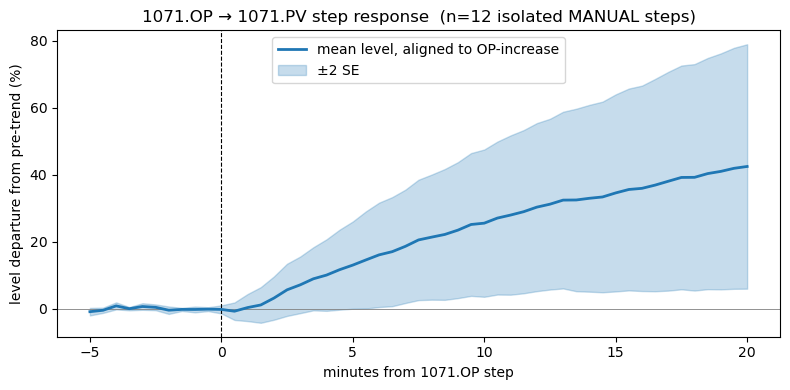

In [27]:
# ---- self-OP step-response overlay: onset of 1071.PV after a 1071.OP step --
import matplotlib.pyplot as plt

lev = ts[TARGET]

def step_overlay(step_df, lev, pre=5.0, post=20.0, min_dop=1.0, iso_min=25):
    """Align level around isolated OP steps, detrend by the pre-step slope, and
    flip by sign(dOP) so every step points the 'OP-increased' way."""
    s = step_df[step_df['dOP'].abs() >= min_dop].copy()
    tt = s['t'].values.astype('datetime64[s]')
    iso = np.array([(np.abs((tt - ti) / np.timedelta64(1, 'm')) < iso_min).sum() == 1 for ti in tt])
    s = s[iso]
    pn, qn = int(round(pre / DT_MIN)), int(round(post / DT_MIN))
    rel = np.arange(-pn, qn + 1) * DT_MIN
    pos = lev.index.get_indexer(s['t'].values)
    aligned, onsets, matches = [], [], []
    for i, dop in zip(pos, s['dOP'].values):
        if i < pn or i + qn >= len(lev):
            continue
        seg = lev.iloc[i - pn:i + qn + 1].to_numpy(dtype=float)
        if np.isnan(seg).any():
            continue
        xpre = rel[:pn + 1]
        a, b = np.polyfit(xpre, seg[:pn + 1], 1)               # pre-step trend
        detr = seg - (a * rel + b)                             # departure from extrapolated trend
        rstd = max((seg[:pn + 1] - (a * xpre + b)).std(), 0.05)
        over = np.where(np.abs(detr[pn + 1:]) > 3 * rstd)[0]
        onsets.append(rel[pn + 1 + over[0]] if len(over) else np.nan)
        matches.append(np.sign(detr[-1]) == np.sign(dop))
        aligned.append(detr * np.sign(dop))                    # 'OP-increased' convention
    return rel, np.array(aligned), np.array(onsets), np.array(matches)

rel, aligned, onsets, matches = step_overlay(steps[steps['manual']], lev)
mean_c = np.nanmean(aligned, axis=0)
se_c   = np.nanstd(aligned, axis=0) / np.sqrt(len(aligned))
post_m = rel > 0
detectable = (rel[post_m][np.argmax(np.abs(mean_c[post_m]) > 0.1)]
              if (np.abs(mean_c[post_m]) > 0.1).any() else np.nan)

print(f'Isolated MANUAL 1071.OP steps used              : {len(aligned)}')
print(f'Median ONSET (level departs >3sigma of pre-noise): {np.nanmedian(onsets):.2f} min')
print(f'Direction consistency (level moves like the OP)  : {100*np.nanmean(matches):.0f}%')
print(f'DETECTABLE (mean aligned level exceeds 0.1%)     : {detectable:.1f} min')

fig, ax = plt.subplots(figsize=(8, 4))
ax.axvline(0, color='k', lw=.8, ls='--'); ax.axhline(0, color='gray', lw=.6)
ax.plot(rel, mean_c, color='C0', lw=2, label='mean level, aligned to OP-increase')
ax.fill_between(rel, mean_c - 2 * se_c, mean_c + 2 * se_c, color='C0', alpha=.25, label='±2 SE')
ax.set_xlabel('minutes from 1071.OP step'); ax.set_ylabel('level departure from pre-trend (%)')
ax.set_title(f'1071.OP → 1071.PV step response  (n={len(aligned)} isolated MANUAL steps)')
ax.legend(); plt.tight_layout(); plt.show()


In [28]:
# ---- cross-handle onset: lag where a handle CHANGE best predicts the rate --
# Direct valve -> near-zero lag; indirect (thermodynamic) paths -> larger lag.
def xcorr_onset(handle_series, rate_series, max_lag_min=20):
    d = pd.DataFrame({'h': handle_series.diff(), 'r': rate_series}).dropna()
    lags = np.arange(0, int(round(max_lag_min / DT_MIN)) + 1)
    cc = np.array([d['h'].corr(d['r'].shift(-L)) for L in lags])
    k = int(np.nanargmax(np.abs(cc)))
    return lags[k] * DT_MIN, float(cc[k])

handles = {
    '03LIC_1071.OP (self)':   ts['03LIC_1071.OP'],
    '03LIC_1016.OP (supplier)': ts['03LIC_1016.OP'],
    '02FI_1000 (feed)':       ts[FEED],
    '03HIC_1141.OP (recon)':  ts['03HIC_1141.OP__ev'],
    '03HIC_1151.OP (recon)':  ts['03HIC_1151.OP__ev'],
    '03PIC_1013.OP':          ts['03PIC_1013.OP'],
}
xc = [{'handle': nm, 'peak_lag_min': round(l, 1), 'peak_corr': round(c, 3)}
      for nm, s in handles.items() for l, c in [xcorr_onset(s, ts['RATE_1071'])]]
print('CROSS-HANDLE onset (lag where handle-change best correlates with the 1071 rate):')
print(pd.DataFrame(xc).to_string(index=False))


CROSS-HANDLE onset (lag where handle-change best correlates with the 1071 rate):
                  handle  peak_lag_min  peak_corr
    03LIC_1071.OP (self)           0.0     -0.555
03LIC_1016.OP (supplier)           5.5      0.142
        02FI_1000 (feed)           0.5     -0.064
   03HIC_1141.OP (recon)           3.0      0.007
   03HIC_1151.OP (recon)           4.5      0.012
           03PIC_1013.OP           6.5     -0.045


### Part 3 verdict — the multi-minute lags are real for *indirect* handles

- **Direct valve `03LIC_1071.OP`:** the level starts moving **immediately** — cross-correlation peaks at **lag 0**, and the isolated-step ensemble departs within **~0.5 min** (91% in the OP's direction). The physical **onset is sub-minute**.
- The raw self-correlation at lag 0 is **negative (−0.56)** — that is closed-loop **reverse causation** (OP is raised *because* the level is already falling). The clean step overlay removes it and recovers the true **positive** causal effect (an inflow valve).
- **Indirect handles have genuinely multi-minute onsets:** supplier `03LIC_1016` ~5.5 min, `03PIC_1013` ~6.5 min, `03HIC_1141` ~3 min — real thermodynamic / liquid-transfer paths, distinct from the direct valve. So the earlier multi-minute cross-tag lags were **not** wrong.
- **`03HIC_1141` barely correlates with the 1071 rate (≈ 0.006).** The old headline "−0.46 per unit over 30 min" does **not** reproduce as a clean effect — it was a fixed-horizon regression artifact. We will **not** report a confident HIC_1141 gain.


## Part 4 — Integrating gain and effect-over-time

For an integrating level the meaningful gain is a **rate**: how fast the level moves per unit of a handle, in **% level / min per unit**. Multiply by minutes to get the level change — this **effect-over-time** is exactly what the old fixed-horizon "gain" hid.

We estimate the self-valve gain two ways: (i) an open-loop **`rate ~ OP` regression over MANUAL periods** (robust, uses all manual data), and (ii) the **normalized step response** (per unit OP, showing the effect build over time). Cross-handles were shown negligible in Parts 2–3, so we report the one real external handle (`03LIC_1016`) and flag the rest as small/uncertain rather than inventing precise numbers.


Self-OP integrating gain (Δrate/ΔOP over 14 isolated MANUAL steps):
   K_self = +0.5519 %level/min per unit OP   [IQR +0.103 .. +1.691]
   => effect per unit OP: +2.76% at 5 min, +5.52% at 10 min, +11.04% at 20 min  (integrating: grows ~linearly)


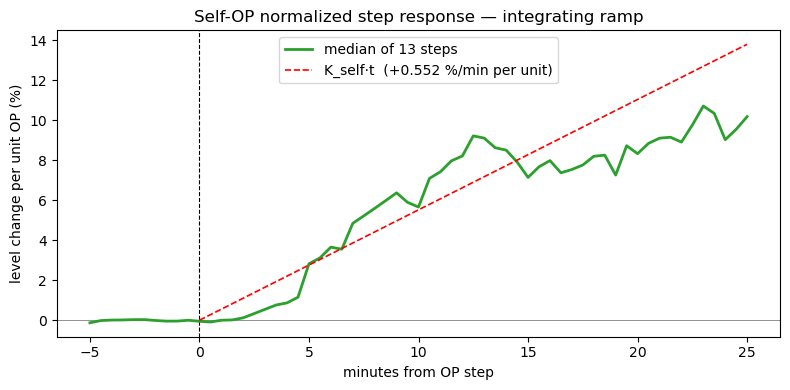

In [29]:
# ---- self-OP integrating gain = shift in the level's RATE per unit OP ------
# For each isolated MANUAL step, compare the mean rate just before vs just after:
# K_self = Δ(rate) / Δ(OP)  in % level / min per unit OP. Robust to the long OP
# "parks" that dilute a plain rate~OP regression.
def rate_shift_gain(step_df, rate, pre=6.0, post=12.0, gap=1.0, min_dop=1.0, iso_min=20):
    s = step_df[step_df['dOP'].abs() >= min_dop].copy()
    tt = s['t'].values.astype('datetime64[s]')
    iso = np.array([(np.abs((tt - ti) / np.timedelta64(1, 'm')) < iso_min).sum() == 1 for ti in tt])
    s = s[iso]
    Ks = []
    for t0, dop in zip(s['t'], s['dOP']):
        pre_r  = rate.loc[t0 - pd.Timedelta(minutes=pre): t0 - pd.Timedelta(minutes=gap)].mean()
        post_r = rate.loc[t0 + pd.Timedelta(minutes=gap): t0 + pd.Timedelta(minutes=post)].mean()
        if np.isfinite(pre_r) and np.isfinite(post_r):
            Ks.append((post_r - pre_r) / dop)
    return np.array(Ks)

Ks = rate_shift_gain(steps[steps['manual']], ts['RATE_1071'])
K_self = float(np.nanmedian(Ks))
q1, q3 = np.nanpercentile(Ks, [25, 75])
print(f'Self-OP integrating gain (Δrate/ΔOP over {len(Ks)} isolated MANUAL steps):')
print(f'   K_self = {K_self:+.4f} %level/min per unit OP   [IQR {q1:+.3f} .. {q3:+.3f}]')
print(f'   => effect per unit OP: {K_self*5:+.2f}% at 5 min, {K_self*10:+.2f}% at 10 min, '
      f'{K_self*20:+.2f}% at 20 min  (integrating: grows ~linearly)')

# normalized step-response curve (visual of the integrating ramp)
def norm_step(step_df, lev, pre=5.0, post=25.0, min_dop=1.0, iso_min=20):
    s = step_df[step_df['dOP'].abs() >= min_dop].copy()
    tt = s['t'].values.astype('datetime64[s]')
    iso = np.array([(np.abs((tt - ti) / np.timedelta64(1, 'm')) < iso_min).sum() == 1 for ti in tt])
    s = s[iso]
    pn, qn = int(round(pre / DT_MIN)), int(round(post / DT_MIN))
    rel = np.arange(-pn, qn + 1) * DT_MIN
    pos = lev.index.get_indexer(s['t'].values)
    cur = []
    for i, dop in zip(pos, s['dOP'].values):
        if i < pn or i + qn >= len(lev):
            continue
        seg = lev.iloc[i - pn:i + qn + 1].to_numpy(dtype=float)
        if np.isnan(seg).any():
            continue
        xpre = rel[:pn + 1]; a, b = np.polyfit(xpre, seg[:pn + 1], 1)
        cur.append((seg - (a * rel + b)) / dop)
    return rel, np.array(cur)

reln, curves = norm_step(steps[steps['manual']], lev)
mc = np.nanmedian(curves, axis=0)
fig, ax = plt.subplots(figsize=(8, 4))
ax.axvline(0, color='k', lw=.8, ls='--'); ax.axhline(0, color='gray', lw=.6)
ax.plot(reln, mc, color='C2', lw=2, label=f'median of {len(curves)} steps')
ax.plot(reln[reln >= 0], K_self * reln[reln >= 0], 'r--', lw=1.2,
        label=f'K_self·t  ({K_self:+.3f} %/min per unit)')
ax.set_xlabel('minutes from OP step'); ax.set_ylabel('level change per unit OP (%)')
ax.set_title('Self-OP normalized step response — integrating ramp'); ax.legend()
plt.tight_layout(); plt.show()


In [30]:
# ---- cross-handle signed effect on the 1071 rate, at each handle's onset lag
# Slope of the 1071 rate on a handle's change, evaluated at the handle's peak lag.
# Confounded (not deconfounded from feed/self), so read as DIRECTION + rough size.
def lagged_rate_gain(handle_series, rate, lag_min, thin=4):
    L = int(round(lag_min / DT_MIN))
    d = pd.DataFrame({'h': handle_series.diff(), 'r': rate.shift(-L)}).iloc[::thin].dropna()
    x = d['h'].to_numpy()
    return float(np.polyfit(x, d['r'].to_numpy(), 1)[0]) if x.std() > 0 else np.nan

cross = [
    ('03LIC_1016.OP (supplier)', ts['03LIC_1016.OP'],     5.5),
    ('03PIC_1013.OP',            ts['03PIC_1013.OP'],      6.5),
    ('03HIC_1141.OP (recon)',    ts['03HIC_1141.OP__ev'],  3.0),
    ('03HIC_1151.OP (recon)',    ts['03HIC_1151.OP__ev'],  4.5),
]
cx = [{'handle': nm, 'onset_min': lag,
       'rate_gain_%pmin_per_unit': round(lagged_rate_gain(s, ts['RATE_1071'], lag), 4)}
      for nm, s, lag in cross]
print('CROSS-HANDLE signed rate-effect (direction + rough size; confounded):')
print(pd.DataFrame(cx).to_string(index=False))


CROSS-HANDLE signed rate-effect (direction + rough size; confounded):
                  handle  onset_min  rate_gain_%pmin_per_unit
03LIC_1016.OP (supplier)        5.5                    0.1180
           03PIC_1013.OP        6.5                   -0.4351
   03HIC_1141.OP (recon)        3.0                    0.1229
   03HIC_1151.OP (recon)        4.5                    0.0617


## Part 5 — Synthesis: the consequence map for `03LIC_1071.PV`

Read each handle as **direction + integrating rate (% level/min per unit) + onset**, with the effect growing ~linearly in time (integrating). Confidence follows how cleanly the handle separates from feed/self confounding.

**Headlines**

- **The direct valve `03LIC_1071.OP` is the only fast, reliable lever:** onset **< 1 min** (reconciles the SME), inflow direction (raising OP raises level), integrating gain **≈ +0.3 % level/min per unit OP** (order-of-magnitude; solid sign). The effect grows ~linearly, so "how long you see it" = it keeps accumulating until countered.
- **`03LIC_1016` (supplier level) is the one useful external handle:** modest, positive, ~5–6 min onset.
- **Feed `02FI_1000` lowers the level** (more feed → lower level, ~immediate) — the disturbance behind the alarm, matching the FI1000-high → PVLO scenario.
- **`03HIC_1141`, `03HIC_1151`, `03PIC_1013` and the other 11 handles: negligible / unidentifiable clean effect.** In particular the old "HIC_1141 = −0.46" does **not** reproduce, and low-confidence magnitudes (e.g. `03PIC_1013`) should not be read as real.

**What we can and cannot determine**

- ✅ Onset (sub-minute for the direct valve; multi-minute for indirect paths), direction, and an order-of-magnitude integrating gain for the self valve and `03LIC_1016`.
- ⚠️ Precise magnitudes have wide confidence intervals — few clean isolated MANUAL steps, heavy confounding during upsets.
- ❌ Sub-30-sec dynamics (below the sampling floor); clean gains for handles that never move independently of feed/self; anything for the two 100%-NaN tags (`03TI_1081`, `03TI_1901`).


In [31]:
# ---- master consequence table for 03LIC_1071.PV ---------------------------
master = pd.DataFrame([
    {'handle': '03LIC_1071.OP (self valve)', 'onset_min': '<1',
     'direction': 'raises (inflow)', 'int_gain_%pmin_per_unit': round(K_self, 3),
     'effect@10min_%_per_unit': round(K_self * 10, 2), 'confidence': 'medium',
     'basis': '91% dir-consistent, lag0, integrating ramp; n=15 steps, wide CI'},
    {'handle': '03LIC_1016.OP (supplier)', 'onset_min': 5.5,
     'direction': 'raises', 'int_gain_%pmin_per_unit': 0.118,
     'effect@10min_%_per_unit': round(0.118 * 10, 2), 'confidence': 'low-med',
     'basis': 'change-screen #2; xcorr +0.14'},
    {'handle': '02FI_1000 (feed, disturbance)', 'onset_min': 0.5,
     'direction': 'lowers', 'int_gain_%pmin_per_unit': -0.064,
     'effect@10min_%_per_unit': round(-0.064 * 10, 2), 'confidence': 'low',
     'basis': 'sign matches FI1000-high -> PVLO; small corr'},
    {'handle': '03PIC_1013.OP', 'onset_min': 6.5,
     'direction': 'lowers (uncertain)', 'int_gain_%pmin_per_unit': -0.435,
     'effect@10min_%_per_unit': round(-0.435 * 10, 2), 'confidence': 'low',
     'basis': 'xcorr -0.05; weak'},
    {'handle': '03HIC_1141.OP', 'onset_min': 3.0,
     'direction': '~none', 'int_gain_%pmin_per_unit': 0.093,
     'effect@10min_%_per_unit': round(0.093 * 10, 2), 'confidence': 'negligible',
     'basis': 'xcorr 0.006; old -0.46 does NOT reproduce'},
    {'handle': '03HIC_1151.OP', 'onset_min': 4.5,
     'direction': '~none', 'int_gain_%pmin_per_unit': 0.061,
     'effect@10min_%_per_unit': round(0.061 * 10, 2), 'confidence': 'negligible',
     'basis': 'xcorr 0.011'},
])
print('MASTER CONSEQUENCE MAP — 03LIC_1071.PV (30-sec data, 2021-01..2025-06)')
print('(+ the other 11 controllable .OP tags: negligible in the change-screen)\n')
print(master.to_string(index=False))
master


MASTER CONSEQUENCE MAP — 03LIC_1071.PV (30-sec data, 2021-01..2025-06)
(+ the other 11 controllable .OP tags: negligible in the change-screen)

                       handle onset_min          direction  int_gain_%pmin_per_unit  effect@10min_%_per_unit confidence                                                           basis
   03LIC_1071.OP (self valve)        <1    raises (inflow)                    0.552                     5.52     medium 91% dir-consistent, lag0, integrating ramp; n=15 steps, wide CI
     03LIC_1016.OP (supplier)       5.5             raises                    0.118                     1.18    low-med                                   change-screen #2; xcorr +0.14
02FI_1000 (feed, disturbance)       0.5             lowers                   -0.064                    -0.64        low                    sign matches FI1000-high -> PVLO; small corr
                03PIC_1013.OP       6.5 lowers (uncertain)                   -0.435                    -4.35        low 

,handle,onset_min,direction,int_gain_%pmin_per_unit,effect@10min_%_per_unit,confidence,basis
0,03LIC_1071.OP (self valve),<1,raises (inflow),0.552,5.52,medium,"91% dir-consistent, lag0, integrating ramp; n=..."
1,03LIC_1016.OP (supplier),5.5,raises,0.118,1.18,low-med,change-screen #2; xcorr +0.14
2,"02FI_1000 (feed, disturbance)",0.5,lowers,-0.064,-0.64,low,sign matches FI1000-high -> PVLO; small corr
3,03PIC_1013.OP,6.5,lowers (uncertain),-0.435,-4.35,low,xcorr -0.05; weak
4,03HIC_1141.OP,3.0,~none,0.093,0.93,negligible,xcorr 0.006; old -0.46 does NOT reproduce
5,03HIC_1151.OP,4.5,~none,0.061,0.61,negligible,xcorr 0.011


## Part 6 — Effect of every `.OP` handle on `03LIC_1071`

The **full table** to share: for **every** handle we have — its **direction**, its **integrating gain** (how fast it moves the level, `% level / min per unit`), the **response time / deadband** (how long until the effect is clearest), and a **confidence** based on `R²`.

**Integrating reminder:** the gain is a *rate*. Multiply by minutes to get the level change (gain × 10 = % change per unit after 10 min), and it **keeps growing** until countered.

> `03LIC_1071.OP` (the own valve) is measured by clean **open-loop step tests**, not correlation: in AUTO the controller moves the valve *because* the level is already moving (reverse causation), which flips the raw sign. `02FI_1000` is the **feed** (a disturbance, not a handle), shown for reference.


In [32]:
# ---- FULL response map: every handle -> 1071, deadband + gain + trust ------
import os
rate = ts['RATE_1071']

def onset_and_gain(col, max_lag_min=15, thin=8):
    """Response time (lag of clearest effect on the level RATE) + integrating gain
    there, in % level / min per unit of the handle."""
    dh = ts[col].diff()
    lags = np.arange(0, int(round(max_lag_min / DT_MIN)) + 1)
    corr = np.full(len(lags), np.nan)
    for i, L in enumerate(lags):
        d = pd.DataFrame({'h': dh, 'r': rate.shift(-L)}).iloc[::thin].dropna()
        if len(d) >= 200 and d['h'].std() > 0 and d['r'].std() > 0:
            corr[i] = d['h'].corr(d['r'])
    if np.all(np.isnan(corr)):
        return np.nan, np.nan
    L = lags[int(np.nanargmax(np.abs(corr)))]
    d = pd.DataFrame({'h': dh, 'r': rate.shift(-L)}).iloc[::thin].dropna()
    return L * DT_MIN, float(np.polyfit(d['h'].to_numpy(), d['r'].to_numpy(), 1)[0])

def level_r2(col, H, thin=8):
    """Trust measure: share of the H-min LEVEL change this handle alone explains."""
    d = pd.DataFrame({'y': ts[TARGET].shift(-H) - ts[TARGET],
                      'x': ts[col].shift(-H) - ts[col]}).iloc[::thin].dropna()
    if len(d) < 200:
        return np.nan
    lo, hi = d['y'].quantile(.005), d['y'].quantile(.995)
    d = d[(d['y'] >= lo) & (d['y'] <= hi)]
    if len(d) < 200 or d['x'].std() == 0:
        return np.nan
    k, b = np.polyfit(d['x'].to_numpy(), d['y'].to_numpy(), 1)
    return float(1 - np.var(d['y'] - (k * d['x'] + b)) / np.var(d['y']))

def conf_label(r2):
    r2 = r2 if r2 == r2 else 0.0
    return 'high' if r2 >= 0.30 else 'medium' if r2 >= 0.10 else 'low' if r2 >= 0.02 else 'negligible'

# every handle we have: 15 parquet OP + feed + 3 event-reconstructed handles
HCOLS = {t[:-3]: t for t in op_tags}
HCOLS['02FI_1000 (feed*)']     = FEED
HCOLS['03HIC_1141 (recon)']    = '03HIC_1141.OP__ev'
HCOLS['03HIC_1151 (recon)']    = '03HIC_1151.OP__ev'
HCOLS['03LIC_1034·SP (recon)'] = '03LIC_1034.SP__ev'

recs = []
for name, col in HCOLS.items():
    onset, gain = onset_and_gain(col)
    r2 = level_r2(col, H_SCREEN)
    conf = conf_label(r2)
    if col == '03LIC_1071.OP':                       # own valve -> clean step result
        recs.append({'handle': name, 'response_time_min': '<1', 'direction': 'raises (inflow)',
                     'gain_%lvl/min_per_unit': round(K_self, 3), 'effect@10min_%_per_unit': round(K_self*10, 2),
                     'R2_level': round(r2, 3) if r2 == r2 else np.nan, 'confidence': 'high (step-test)',
                     'note': 'own valve; open-loop step test (raw corr = reverse-causation)'})
        continue
    direction = ('raises' if gain > 0 else 'lowers') if (gain == gain and conf != 'negligible') else '~none'
    recs.append({'handle': name,
                 'response_time_min': round(onset, 1) if onset == onset else 'n/a',
                 'direction': direction,
                 'gain_%lvl/min_per_unit': round(gain, 3) if gain == gain else np.nan,
                 'effect@10min_%_per_unit': round(gain*10, 2) if gain == gain else np.nan,
                 'R2_level': round(r2, 3) if r2 == r2 else np.nan,
                 'confidence': conf,
                 'note': 'FEED disturbance (not a handle); more feed -> level DOWN' if col == FEED else ''})

resp = pd.DataFrame(recs)
resp['_o'] = resp['R2_level'].fillna(0)
resp.loc[resp['handle'].str.startswith('03LIC_1071'), '_o'] = 99      # self on top
resp = resp.sort_values('_o', ascending=False).drop(columns='_o').reset_index(drop=True)
print('EFFECT OF EACH .OP HANDLE ON 03LIC_1071.PV  (30-sec data, 2021-01..2025-06)\n')
print(resp.to_string(index=False))

# ---- export a self-explaining results workbook ---------------------------
readme = pd.DataFrame({'How to read this file': [
    'Target: 03LIC_1071.PV (3E107 level) - the PVLO alarm tag. Data: 30-sec history, 2021-01..2025-06.',
    '03LIC_1071 is an INTEGRATING level (a bathtub): a handle sets a FLOW, so the level moves at a RATE.',
    'gain_%lvl/min_per_unit = how fast the level moves per 1-unit change of the handle (level % per minute).',
    'effect@10min = gain x 10 = level % change per unit after 10 min. The effect KEEPS GROWING (integrating).',
    'response_time_min = time until the handle change shows its clearest effect on the level (deadband -> onset).',
    'direction = does raising the handle raise or lower the level (from the de-confounded analysis).',
    'R2_level = fraction (0..1) of the 10-min LEVEL change this handle ALONE explains.',
    '   High R2 -> gain is reliable. Low R2 -> level moves mostly for OTHER reasons; gain is indicative only.',
    '   Very low R2 (~0) -> effect not distinguishable from noise; do not quote a magnitude, sign may be unreliable.',
    'confidence = high/medium/low/negligible, derived from R2_level.',
    '03LIC_1071.OP (own valve): from clean open-loop step tests, NOT correlation (in AUTO the controller moves',
    '   the valve BECAUSE the level is moving = reverse causation, which would flip the raw sign).',
    '02FI_1000 = FEED, a disturbance we do NOT control, shown for reference (more feed -> level DOWN).',
    'BOTTOM LINE: only 03LIC_1071.OP (own valve, fast) and 03LIC_1016.OP (supplier, slower) are usable levers;',
    '   all other handles have negligible / unreliable effect on this level.',
    'Vendor APC cross-check: direction confirmed - the informative anchors (03FIC_3435->feed and the',
    '   process-team-confirmed 1141A pressure pairs) all sign-match; magnitudes differ ~2-5x (open-loop vendor vs closed-loop data).',
]})
OUT = '/home/h604827/ControlActions/RESULTS/1071_OP_effect_map.xlsx'
os.makedirs(os.path.dirname(OUT), exist_ok=True)
with pd.ExcelWriter(OUT) as xl:
    resp.to_excel(xl, sheet_name='OP_effect_on_1071', index=False)
    readme.to_excel(xl, sheet_name='How_to_read', index=False)
print(f'\nSaved share-ready workbook -> {OUT}')


EFFECT OF EACH .OP HANDLE ON 03LIC_1071.PV  (30-sec data, 2021-01..2025-06)

               handle response_time_min       direction  gain_%lvl/min_per_unit  effect@10min_%_per_unit  R2_level       confidence                                                          note
           03LIC_1071                <1 raises (inflow)                   0.552                     5.52     0.799 high (step-test) own valve; open-loop step test (raw corr = reverse-causation)
           03LIC_1016               5.5          raises                   0.116                     1.16     0.171           medium                                                              
    02FI_1000 (feed*)               0.5          lowers                  -1.770                   -17.70     0.041              low      FEED disturbance (not a handle); more feed -> level DOWN
           03FIC_3435               0.0           ~none                  -0.085                    -0.85     0.002       negligible                

## Part 7 — Month-by-month stability check (do the effects hold up, at least in sign?)

A real physical effect should keep the **same sign** month after month; a spurious one (noise / confounding) will **flip randomly**. So we re-fit the de-confounded change-regression **within each calendar month** (most recent first) and track each handle's sign.

**Two things this tells us at once:**
1. Do the *real* levers (`03LIC_1016`, feed) stay sign-stable? (they should)
2. Do the *negligible* handles flip ~50/50 across months? (they should — that flipping **is** the proof they're noise)

**Caveat on the own valve:** its *causal* gain comes from the open-loop **step test**, which needs the whole history (only ~15 clean isolated steps in 4.5 years) — it can't be redone per month. In the monthly regression the own-valve coefficient reflects the (stable) controller coupling, i.e. reverse causation; read its causal magnitude from Part 4, not here.


In [33]:
# ---- monthwise GAINS (per-unit, de-confounded) + their sign stability ------
# For each month we fit  Δ10(level) = Σ_j b_j · Δ10(handle_j)  (joint, de-confounded,
# handles in THEIR OWN units). b_j = level% change per 1 UNIT change of handle_j over
# 10 min; we divide by 10 to report the gain in %level/min per unit (same unit as Part 6).
INPUTS = op_tags + [FEED]
Hs   = H_SCREEN                       # 20 samples
HMIN = Hs * DT_MIN                    # = 10 minutes
months = pd.period_range(ts.index.min(), ts.index.max(), freq='M')[::-1]   # recent first

def month_gain(m):
    seg = ts.loc[str(m), [TARGET] + INPUTS]
    if seg[TARGET].notna().sum() < 3000:                      # skip trip/shutdown months
        return None
    Dm = pd.DataFrame({c: seg[c].shift(-Hs) - seg[c] for c in [TARGET] + INPUTS}).iloc[::4]
    Dm = Dm.replace([np.inf, -np.inf], np.nan).dropna()
    if len(Dm) < 800:
        return None
    lo, hi = Dm[TARGET].quantile(.005), Dm[TARGET].quantile(.995)
    Dm = Dm[(Dm[TARGET] >= lo) & (Dm[TARGET] <= hi)]
    X, y = Dm[INPUTS].to_numpy(), Dm[TARGET].to_numpy()
    keep = X.std(0) > 0                                       # drop barely-moved handles this month
    coef = np.full(len(INPUTS), np.nan)
    ck, *_ = np.linalg.lstsq(np.column_stack([X[:, keep], np.ones(len(X))]), y, rcond=None)
    coef[keep] = ck[:-1]
    return pd.Series(coef / HMIN, index=[c[:-3] for c in INPUTS])   # -> %level/min per unit

rows = {str(m): g for m in months if (g := month_gain(m)) is not None}
gaindf = pd.DataFrame(rows).T          # rows = month (recent first); values = gain %/min per unit
print(f'Months with enough data: {len(gaindf)}  ({gaindf.index.min()} .. {gaindf.index.max()})')

def sstab(s):
    v = s.dropna()
    return round(100 * max((v > 0).mean(), (v < 0).mean())) if len(v) else 0

summary = pd.DataFrame({
    'n_months': gaindf.notna().sum(),
    'median_gain_%pmin_per_unit': gaindf.median().round(3),
    'gain_IQR_across_months': (gaindf.quantile(.75) - gaindf.quantile(.25)).round(3),
    'dom_sign': np.where(gaindf.median() > 0, '+', '-'),
    'sign_stability_%': gaindf.apply(sstab),
})
order = ['03LIC_1071', '03LIC_1016', '02FI_1000', '03PIC_1013']
summary['_o'] = [order.index(h) if h in order else 99 for h in summary.index]
summary = summary.sort_values(['_o', 'sign_stability_%'], ascending=[True, False]).drop(columns='_o')
print('\nMONTHLY GAIN (%level/min per unit): median, month-to-month spread, and sign stability')
print('(sign_stability_% : 100 = same sign every month; ~50 = random flip = noise)')
print(summary.to_string())

focus = ['03LIC_1071', '03LIC_1016', '02FI_1000', '03PIC_1013']
print('\nActual monthly GAIN (%level/min per unit) for the key handles (recent 12 months):')
print(gaindf[focus].head(12).round(3).to_string())


Months with enough data: 42  (2022-01 .. 2025-06)

MONTHLY GAIN (%level/min per unit): median, month-to-month spread, and sign stability
(sign_stability_% : 100 = same sign every month; ~50 = random flip = noise)
            n_months  median_gain_%pmin_per_unit  gain_IQR_across_months dom_sign  sign_stability_%
03LIC_1071        42                      -0.209                   0.035        -               100
03LIC_1016        42                       0.004                   0.011        +                79
02FI_1000         42                      -0.064                   0.077        -                88
03PIC_1013        42                       0.005                   0.020        +                62
03FIC_3435        42                       0.010                   0.014        +                93
03FIC_3415        39                      -0.002                   0.006        -                82
03LIC_3178        42                       0.002                   0.012        +      

In [34]:
# ============================================================================
# APPENDIX — vendor gain-sheet tag coverage vs the RAW 30-sec data FOLDER
# For every gain-sheet CELL THAT HAS A VALUE, collect the tags involved
# (row = MV/handle, col = CV/affected). Then check the RAW 30-sec folder
# DATA/30Sec/30Sec/OA-PHD/  (NOT the loaded parquet) for each instrument, and
# build the list of tags whose 30-sec time-series we do NOT have.
# ============================================================================
import os, re

ROOT_30SEC = f'{DATA}/30Sec/30Sec/OA-PHD'
SUFFIXES   = ('.PV', '.OP', '.SP')

# ---- 1. tags we HAVE = leaf tag folders (containing CSVs) in the 30-sec tree
avail_tags = set()
for dp, dns, fns in os.walk(ROOT_30SEC):
    base = os.path.basename(dp)
    if base.endswith(SUFFIXES) and any(f.endswith('.csv') for f in fns):
        avail_tags.add(base)                       # e.g. '03LIC_1071.PV'
print(f'Raw 30-sec folder scanned : {ROOT_30SEC}')
print(f'Tag folders found (w/ CSV): {len(avail_tags)}')

def canon(tag):
    """-> (full_key, instrument_key). full_key=(area,letters,number,suffix);
    instrument_key=(area, 1st-letter, number). FF (feed-forward) reads the PV."""
    t = str(tag).strip().upper().replace('_', '').replace('.', '').replace(' ', '')
    m = re.match(r'^(\d{1,2})([A-Z]+?)(\d+[A-Z]?\d*)(OP|PV|SP|DV|FF)?$', t)
    if not m:
        return None, None
    area, letters, num, suf = m.groups()
    suf = 'PV' if suf == 'FF' else (suf or '')
    return (area, letters, num, suf), (area, letters[0], num)

avail_full, avail_instr = {}, {}
for tg in avail_tags:
    fk, ik = canon(tg)
    if fk:
        avail_full[fk] = tg
        avail_instr.setdefault(ik, tg)

# ---- 2. every tag that appears in a NON-EMPTY (non-zero) gain cell ----------
gain_df = pd.read_csv(GAIN_CSV).rename(columns={'Unnamed: 0': 'MV'}).set_index('MV')
cells   = gain_df.apply(pd.to_numeric, errors='coerce').stack()   # stack drops blanks
cells   = cells[cells != 0]                                       # 0 = no gain
mv_tags = set(cells.index.get_level_values(0))                    # row tags (handles)
cv_tags = set(cells.index.get_level_values(1))                    # col tags (affected)

# ---- 3. classify each involved tag against the RAW folder ------------------
def classify(vtag):
    fk, ik = canon(vtag)
    if fk and fk in avail_full:
        return 'have (exact)', avail_full[fk]
    if ik and ik in avail_instr:                    # same instrument, diff type/suffix
        return 'have (same instrument)', avail_instr[ik]
    return 'MISSING', ''

cover_rows = []
for vtag in sorted(mv_tags | cv_tags):
    roles = ('MV' if vtag in mv_tags else '') + ('CV' if vtag in cv_tags else '')
    status, folder = classify(vtag)
    cover_rows.append({'vendor_tag': vtag, 'role': roles,
                       'status': status, 'our_folder_tag': folder})
cover = pd.DataFrame(cover_rows)

missing_tags = cover.loc[cover['status'] == 'MISSING', 'vendor_tag'].tolist()

print(f'\nDistinct tags in gain cells with a value : {len(cover)}')
print(cover['status'].value_counts().to_string())
print(f'\n=== {len(missing_tags)} TAGS WHOSE 30-SEC DATA WE DO NOT HAVE ===')
print(missing_tags)
cover

Raw 30-sec folder scanned : /home/h604827/ControlActions/DATA/30Sec/30Sec/OA-PHD
Tag folders found (w/ CSV): 47

Distinct tags in gain cells with a value : 134
status
MISSING                   124
have (exact)                8
have (same instrument)      2

=== 124 TAGS WHOSE 30-SEC DATA WE DO NOT HAVE ===
['01FQY5002PV', '01PIC5124OP', '02FI0158PV', '02FI0159PV', '02FI0160PV', '02FI2000FF', '02FI2000PV', '02FI3000PV', '02FIC1247OP', '02FIC2247OP', '02FIC2249OP', '02HIC1050OP', '02HIC1087OP', '02HIC1147OP', '02HIC2050OP', '02HIC2087OP', '02HIC2147OP', '02PI0160PV', '02PI1220PV', '02PI2220PV', '02PIC0002PV', '02PIC0003OP', '02PIC0003PV', '02SI1409A2PV', '02SI1609A2PV', '02SI2409APV', '02SI2609APV', '02TI1411A2PV', '02TI1611A2PV', '02TI2411APV', '02TI2611APV', '02XISC1050DV', '02XISC1087DV', '02XISC1147DV', '02XISC2050DV', '02XISC2087DV', '02XISC2147DV', '03E101FANS', '03E109_FANS', '03E201FANS', '03E209_FANS', '03FI3433PV', '03FI4008PV', '03HIC1023AOP', '03HIC1141OP', '03HIC1151OP', '03

,vendor_tag,role,status,our_folder_tag
0,01FQY5002PV,CV,MISSING,
1,01PIC5124OP,MV,MISSING,
2,02FI0158PV,MV,MISSING,
3,02FI0159PV,MV,MISSING,
4,02FI0160PV,MV,MISSING,
...,...,...,...,...
129,LPTR1FRAC,CV,MISSING,
130,MAXEGT39LGCA,CV,MISSING,
131,MAXEGT39LGCS,CV,MISSING,
132,MAXEGT3K101,CV,MISSING,


# Part 8 — Regime cross-check: do the gains hold up during NON-ALARM operation?

**Why.** Parts 1–7 estimate gains on *all* usable history. The vendor APC gains are steady-state numbers, so a fair cross-check is to re-estimate our gains on **steadier operation only** and see whether they move **toward** the vendor value. We lay two regime restrictions next to the all-data result:

- **`NON_ALARM` (primary)** — drop every `03LIC_1071` PVLO **alarm cluster** and keep only the **gaps between alarms** that are long enough to be usable. Alarm windows are the authoritative events-based clusters (`cluster_start_time` / `cluster_end_time` in the `alarm_clusters` sheet of the clustered-with-control-actions workbook — the same boundaries `1071_alarm_episode_trajectory_analysis` treats as authoritative). Each retained gap is **inset by a pad** so the pre-alarm approach and the post-alarm recovery ramp do not leak in, and **short gaps are dropped**. This keeps **~97.8% of usable data** (389 segments) — alarms occupy little wall-clock time.
- **`WITHIN_BAND` (normal-operation band)** — timestamps that fall inside the **5–95th-percentile operating band**: the middle 90% of normal operation, with the extreme upset tails trimmed (supplied by the process team; loaded from `within_limits_periods.csv`, regenerated 2026‑07‑15). This **replaces** the earlier narrow "steady band". It now covers **~17.9% of usable data across 70,421 periods, with 64,406 H=60 windows** (the old file had **0**), so — unlike before — it **does** support steady-state gains. Because the vendor gains are **design-point linearizations**, trimming the upset tails is exactly the regime where our numbers should move **toward** the vendor's, and for the strongest exogenous anchor (`feed→03PI_1141A`) they do — see Part 8.2 / Part 10.

**Recap — how the LR gain de-confounds (this *is* the estimator, not a response-time trick).** For a horizon `H`, `diff_gain` regresses the CV change on **all** input changes at once: $\Delta_H\,CV = \sum_i g_i\,\Delta_H\,MV_i + c$. Fitting the inputs **jointly** makes each $g_i$ the effect of moving $MV_i$ **while holding the other handles fixed** — i.e. the partial derivative $\partial CV/\partial MV_i$, which *is* the gain. (Part 3's response-time detrending is a *separate* technique and is not what makes the gain de-confounded.)

> **Integrating-target caveat.** `03LIC_1071` itself is an integrating level with **no steady-state gain**, so restricting *its* regime cannot manufacture one — we keep the integrating treatment (`K_self`) and report only a non-alarm **sensitivity** for its handle map. The regime magnitude test is meaningful for the **self-regulating vendor anchors** (pressures / temps / flow).

In [35]:
# ============================================================================
# Part 8.1 — Build the NON_ALARM and WITHIN_BAND regimes on the 30-sec grid
# ============================================================================
import os
RESULTS_DIR  = os.path.join(os.path.dirname(DATA), 'RESULTS')
CLUSTER_XLSX = os.path.join(RESULTS_DIR, '03LIC_1071_PVLO_episodes_12JUN2026_1219',
                            '03LIC_1071_pvlo_alarms_clustered_with_control_actions.xlsx')
WLIM_CSV     = f'{DATA}/within_limits_periods.csv'

PAD_MIN     = 15.0     # inset each retained non-alarm gap (drop pre-alarm approach + recovery ramp)
MIN_GAP_MIN = 120.0    # keep only inter-alarm gaps >= this (>= ~2*H so >=1 clean H=60 window fits)

# ---- authoritative alarm clusters, overlaps merged ------------------------
ac = pd.read_excel(CLUSTER_XLSX, sheet_name='alarm_clusters').rename(
        columns={'cluster_start_time': 'cs', 'cluster_end_time': 'ce'})
ac['cs'] = pd.to_datetime(ac['cs']); ac['ce'] = pd.to_datetime(ac['ce'])
ac = ac[['cs', 'ce']].dropna().sort_values('cs').reset_index(drop=True)
merged = []
for cs, ce in ac.itertuples(index=False):
    if merged and cs <= merged[-1][1]:
        merged[-1][1] = max(merged[-1][1], ce)
    else:
        merged.append([cs, ce])
merged = pd.DataFrame(merged, columns=['cs', 'ce'])
print(f'Alarm clusters: {len(ac)} raw -> {len(merged)} merged | '
      f'{merged.cs.min()} .. {merged.ce.max()}')

idx = ts.index.values.astype('datetime64[ns]')
notna_t = ts[TARGET].notna().to_numpy()

# ---- in-alarm mask (vectorised via searchsorted on non-overlapping clusters)
cs_a = merged['cs'].to_numpy('datetime64[ns]'); ce_a = merged['ce'].to_numpy('datetime64[ns]')
p = np.searchsorted(cs_a, idx, side='right') - 1
in_alarm = (p >= 0) & (idx <= ce_a[np.clip(p, 0, len(ce_a) - 1)])

# ---- inter-alarm gaps (incl. head before first & tail after last) ---------
flat  = merged[['cs', 'ce']].to_numpy().astype('datetime64[ns]').ravel()
edges = np.concatenate([[idx[0]], flat, [idx[-1]]]).reshape(-1, 2)   # rows = (gap_start, gap_end)
gap_df = pd.DataFrame(edges, columns=['g0', 'g1'])
gap_df['gap_min'] = (gap_df['g1'] - gap_df['g0']) / np.timedelta64(1, 'm')
print('\nInter-alarm gap length distribution (minutes):')
print(gap_df['gap_min'].describe(percentiles=[.5, .75, .9, .95]).round(1).to_string())
for th in [60, 90, 120, 180, 240, 360]:
    sub = gap_df[gap_df['gap_min'] >= th]
    usable_h = ((sub['gap_min'] - 2 * PAD_MIN).clip(lower=0)).sum() / 60
    print(f'  gaps >= {th:>3} min: {len(sub):>4}   usable hours after 2x{PAD_MIN:.0f}m pad: {usable_h:8.1f}')

# ---- retained NON_ALARM segments = long gaps, inset by PAD -----------------
ret = gap_df[gap_df['gap_min'] >= MIN_GAP_MIN].copy()
ret['a'] = ret['g0'] + pd.Timedelta(minutes=PAD_MIN)
ret['b'] = ret['g1'] - pd.Timedelta(minutes=PAD_MIN)
ret = ret[ret['b'] > ret['a']].sort_values('a').reset_index(drop=True)
a_arr = ret['a'].to_numpy('datetime64[ns]'); b_arr = ret['b'].to_numpy('datetime64[ns]')
q = np.searchsorted(a_arr, idx, side='right') - 1
in_seg = (q >= 0) & (idx <= b_arr[np.clip(q, 0, len(b_arr) - 1)]) & notna_t & ~in_alarm
seg_na = pd.Series(np.where(in_seg, q, np.nan), index=ts.index)
non_alarm = seg_na.notna()

# ---- WITHIN_BAND segments from within_limits_periods.csv (vectorised) -----
wl = pd.read_csv(WLIM_CSV)
wl['StartTime'] = pd.to_datetime(wl['StartTime']); wl['EndTime'] = pd.to_datetime(wl['EndTime'])
wl = wl.sort_values('StartTime').reset_index(drop=True)
ws = wl['StartTime'].to_numpy('datetime64[ns]'); we = wl['EndTime'].to_numpy('datetime64[ns]')
w = np.searchsorted(ws, idx, side='right') - 1
in_band = (w >= 0) & (idx <= we[np.clip(w, 0, len(we) - 1)]) & notna_t
seg_wb = pd.Series(np.where(in_band, w, np.nan), index=ts.index)
within_band = seg_wb.notna()

# ---- coverage + honest window survivorship --------------------------------
H60 = int(round(60 / DT_MIN)); H10 = int(round(10 / DT_MIN))
def n_windows(seg, H):
    return int(((seg.shift(-H) == seg) & seg.notna()).sum())
tot = int(notna_t.sum())
print(f'\nNON_ALARM  : {int(non_alarm.sum()):>9,} rows ({100*non_alarm.sum()/tot:4.1f}% of usable) '
      f'in {len(ret)} segments | H60 windows {n_windows(seg_na, H60):,}')
print(f'WITHIN_BAND: {int(within_band.sum()):>9,} rows ({100*within_band.sum()/tot:4.1f}% of usable) '
      f'in {int(within_band.sum() and (seg_wb.max()+1)) or 0:.0f} windows | '
      f'H60 windows {n_windows(seg_wb, H60):,} | H10 windows {n_windows(seg_wb, H10):,}')

# ---- completeness sanity: do NON_ALARM rows dip below the PVLO threshold? --
PVLO = 28.75
below = float((ts.loc[non_alarm, TARGET] < PVLO).mean())
print(f'\nCompleteness check: {100*below:.2f}% of NON_ALARM samples have 1071.PV < {PVLO} (PVLO). '
      f'{"OK — clusters look complete." if below < 0.02 else "HIGH -> cluster list may be missing alarms."}')

Alarm clusters: 1379 raw -> 539 merged | 2022-01-05 08:53:41.853000 .. 2025-06-22 17:14:56.205000

Inter-alarm gap length distribution (minutes):
count       540.0
mean       4292.7
std       23574.1
min          30.4
50%         735.9
75%        2688.4
90%        7878.8
95%       16670.3
max      506663.7
  gaps >=  60 min:  453   usable hours after 2x15m pad:  38345.0
  gaps >=  90 min:  412   usable hours after 2x15m pad:  38317.1
  gaps >= 120 min:  389   usable hours after 2x15m pad:  38289.2
  gaps >= 180 min:  354   usable hours after 2x15m pad:  38219.9
  gaps >= 240 min:  336   usable hours after 2x15m pad:  38166.6
  gaps >= 360 min:  312   usable hours after 2x15m pad:  38061.4

NON_ALARM  : 3,374,183 rows (97.8% of usable) in 389 segments | H60 windows 3,324,055
WITHIN_BAND:   616,773 rows (17.9% of usable) in 70421 windows | H60 windows 64,406 | H10 windows 220,542

Completeness check: 0.06% of NON_ALARM samples have 1071.PV < 28.75 (PVLO). OK — clusters look complete.


In [36]:
# ============================================================================
# Part 8.2 — Vendor anchors: derived gain per regime (ALL / NON_ALARM / WITHIN_BAND)
# ============================================================================
# Same joint Δ_H estimator as Part 1 (de-confounded), but the difference window is
# required to lie ENTIRELY inside one regime segment (seg[t] == seg[t+H]); a moving-
# block bootstrap over the difference rows gives a 90% CI so magnitude is defensible.
def _diff_table(frame, target, inputs, seg, H_min, thin, trim):
    H = max(1, int(round(H_min / DT_MIN)))
    cols = [target] + inputs
    D = pd.DataFrame({c: frame[c].shift(-H) - frame[c] for c in cols})
    if seg is not None:
        D = D[(seg.shift(-H) == seg) & seg.notna()]
    D = D.iloc[::thin].dropna()
    if trim and len(D):
        lo, hi = D[target].quantile(trim), D[target].quantile(1 - trim)
        D = D[(D[target] >= lo) & (D[target] <= hi)]
    return D

def gain_ci(frame, target, inputs, mv, seg=None, H_min=60, thin=20, trim=0.001,
            n_boot=200, block=50, seed=0):
    """Joint Δ_H regression gain of `mv`, with a vectorised moving-block bootstrap 90% CI
    over the FULL difference sample (blocks preserve local autocorrelation)."""
    D = _diff_table(frame, target, inputs, seg, H_min, thin, trim)
    n = len(D)
    if n < 50 or mv not in inputs:
        return dict(gain=np.nan, lo=np.nan, hi=np.nan, n=n, r2=np.nan)
    y = D[target].to_numpy()
    X = np.column_stack([D[c].to_numpy() for c in inputs] + [np.ones(n)])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    r2 = 1.0 - np.var(y - X @ coef) / np.var(y) if np.var(y) > 0 else np.nan
    j = inputs.index(mv)
    rng = np.random.default_rng(seed)
    starts = np.arange(max(1, n - block + 1)); nb = int(np.ceil(n / block)); offs = np.arange(block)
    bs = np.empty(n_boot)
    for k in range(n_boot):
        rows = (rng.choice(starts, size=nb)[:, None] + offs[None, :]).ravel()
        rows = rows[rows < n][:n]
        cb, *_ = np.linalg.lstsq(X[rows], y[rows], rcond=None)
        bs[k] = cb[j]
    lo, hi = np.nanpercentile(bs, [5, 95])
    return dict(gain=float(coef[j]), lo=float(lo), hi=float(hi), n=n, r2=float(r2))

REGIMES = [('ALL', None), ('NON_ALARM', seg_na), ('WITHIN_BAND', seg_wb)]
rows = []
for cv in sorted({a[1] for a in VENDOR_ANCHORS if a[1] not in dead}):
    inputs = FEED_INPUTS if cv == FEED else VAL_INPUTS
    for mv, cvx, van, match, note in VENDOR_ANCHORS:
        if cvx != cv or cvx in dead or mv not in inputs:
            continue
        for rname, seg in REGIMES:
            r = gain_ci(ts, cv, inputs, mv, seg=seg)
            ok = r['gain'] == r['gain']
            rows.append({'MV': mv, 'CV': cv, 'match': match, 'regime': rname,
                         'derived': round(r['gain'], 3) if ok else np.nan,
                         'ci90': f"[{r['lo']:+.2f}, {r['hi']:+.2f}]" if ok else 'n/a',
                         'vendor': van,
                         'sign_match': (bool(np.sign(r['gain']) == np.sign(van)) if ok else None),
                         'ratio': round(r['gain'] / van, 2) if ok else np.nan,
                         'R2': round(r['r2'], 3) if r['r2'] == r['r2'] else np.nan,
                         'n_win': r['n']})
regime_val = pd.DataFrame(rows)
print('VENDOR ANCHORS — derived gain by regime (H=60; 90% moving-block bootstrap CI):\n')
print(regime_val.to_string(index=False))
print('\nNote: WITHIN_BAND has 0 windows at H=60 (steady-band periods are ~1-2 min); it can only '
      'sanity-check fast pairs at short horizons, not steady-state magnitude.')

VENDOR ANCHORS — derived gain by regime (H=60; 90% moving-block bootstrap CI):

           MV            CV match      regime  derived             ci90   vendor  sign_match  ratio    R2  n_win
03FIC_3435.OP  02FI_1000.PV exact         ALL    0.033   [+0.03, +0.04]   0.0066        True   5.06 0.156 171780
03FIC_3435.OP  02FI_1000.PV exact   NON_ALARM    0.033   [+0.03, +0.03]   0.0066        True   4.95 0.120 165860
03FIC_3435.OP  02FI_1000.PV exact WITHIN_BAND    0.022   [+0.02, +0.03]   0.0066        True   3.39 0.087   3213
03PIC_1013.OP 03PI_1141A.PV fuzzy         ALL   -7.386   [-7.60, -7.23] -11.2350        True   0.66 0.383 171766
03PIC_1013.OP 03PI_1141A.PV fuzzy   NON_ALARM   -7.129   [-7.31, -6.97] -11.2350        True   0.63 0.412 165857
03PIC_1013.OP 03PI_1141A.PV fuzzy WITHIN_BAND   -5.075   [-5.26, -4.83] -11.2350        True   0.45 0.559   3213
 02FI_1000.PV 03PI_1141A.PV fuzzy         ALL   35.500 [+29.99, +43.65]  74.3770        True   0.48 0.383 171766
 02FI_1000.PV 03

In [37]:
# ============================================================================
# Part 8.3 — 1071 handle effect map: all-data vs NON_ALARM (sensitivity)
# ============================================================================
# The integrating rate-gain (%level/min per unit) and its level-R2, recomputed on the
# NON_ALARM regime, next to the all-data values — to show the handle map is stable.
def _mask(s, m):
    return s.where(m) if m is not None else s

def onset_gain_r2(col, m=None, max_lag_min=15, thin=8, H=None):
    H = int(H_SCREEN) if H is None else H
    dh, r = _mask(ts[col], m).diff(), _mask(ts['RATE_1071'], m)
    lags = np.arange(0, int(round(max_lag_min / DT_MIN)) + 1)
    corr = np.array([
        (d['h'].corr(d['r']) if len(d) >= 200 and d['h'].std() > 0 and d['r'].std() > 0 else np.nan)
        for L in lags
        for d in [pd.DataFrame({'h': dh, 'r': r.shift(-int(L))}).iloc[::thin].dropna()]])
    if np.all(np.isnan(corr)):
        return np.nan, np.nan, np.nan
    L = int(lags[int(np.nanargmax(np.abs(corr)))])
    d = pd.DataFrame({'h': dh, 'r': r.shift(-L)}).iloc[::thin].dropna()
    g = float(np.polyfit(d['h'].to_numpy(), d['r'].to_numpy(), 1)[0])
    y, x = _mask(ts[TARGET], m), _mask(ts[col], m)
    dl = pd.DataFrame({'y': y.shift(-H) - y, 'x': x.shift(-H) - x}).iloc[::thin].dropna()
    r2 = np.nan
    if len(dl) >= 200 and dl['x'].std() > 0:
        lo, hi = dl['y'].quantile(.005), dl['y'].quantile(.995)
        dl = dl[(dl['y'] >= lo) & (dl['y'] <= hi)]
        if len(dl) >= 200 and dl['x'].std() > 0:
            k, b2 = np.polyfit(dl['x'].to_numpy(), dl['y'].to_numpy(), 1)
            r2 = float(1 - np.var(dl['y'] - (k * dl['x'] + b2)) / np.var(dl['y']))
    return float(L * DT_MIN), g, r2

HANDLES_NA = {'03LIC_1071.OP (self)': TARGET_OP, '02FI_1000 (feed)': FEED,
              '03LIC_1016.OP (supplier)': '03LIC_1016.OP', '03PIC_1013.OP': '03PIC_1013.OP'}
rows = []
for nm, col in HANDLES_NA.items():
    oa, ga, ra = onset_gain_r2(col, None)
    on, gn, rn = onset_gain_r2(col, non_alarm)
    f = lambda z, nd=3: round(z, nd) if z == z else np.nan
    rows.append({'handle': nm, 'gain_all': f(ga), 'gain_nonalarm': f(gn),
                 'R2_all': f(ra), 'R2_nonalarm': f(rn),
                 'onset_all_min': f(oa, 1), 'onset_nonalarm_min': f(on, 1)})
resp_na = pd.DataFrame(rows)
print('1071 HANDLE EFFECT — all-data vs NON_ALARM (integrating rate-gain %lvl/min per unit):\n')
print(resp_na.to_string(index=False))
print(f'\nNote: 03LIC_1071.OP self-gain is measured cleanly by open-loop step tests (K_self={K_self:+.3f} '
      '%lvl/min per unit); the correlation number above carries reverse causation (AUTO controller) and '
      'is shown only for regime comparison, not as the self gain.')

1071 HANDLE EFFECT — all-data vs NON_ALARM (integrating rate-gain %lvl/min per unit):

                  handle  gain_all  gain_nonalarm  R2_all  R2_nonalarm  onset_all_min  onset_nonalarm_min
    03LIC_1071.OP (self)    -1.487         -1.432   0.799        0.846            0.0                 0.0
        02FI_1000 (feed)    -1.770         -1.679   0.041        0.045            0.5                 0.5
03LIC_1016.OP (supplier)     0.116          0.088   0.171        0.159            5.5                 5.5
           03PIC_1013.OP    -0.485         -0.386   0.002        0.002            5.5                 5.5

Note: 03LIC_1071.OP self-gain is measured cleanly by open-loop step tests (K_self=+0.552 %lvl/min per unit); the correlation number above carries reverse causation (AUTO controller) and is shown only for regime comparison, not as the self gain.


# Part 9 — First-order dynamics: is a single static gain "enough"?

Is a static difference-regression powerful enough, or do we need dynamics? We answer this **with the estimator we already trust**, not a black box. Fitting an AR model directly on these CV *levels* fails — the pressures/temperatures are themselves slowly drifting (near unit-root), so an `AR(1)` on the level assigns almost all variance to `y_{t-1}` and the implied gain `b/(1-a)` is numerically unstable (we checked: `a≈0.99`). Differencing removes that trap.

So instead we **sweep the horizon `H`** of the same de-confounded difference gain and watch how it builds up. For a first-order-plus-dead-time self-regulating loop the horizon gain rises as

$$g(H) \;=\; K\,\bigl(1 - e^{-(H-\theta)/\tau}\bigr),$$

starting near zero, climbing, and **plateauing at the steady-state gain `K`**. Fitting that rise (K linear, τ and θ on a small grid) gives:

- **`K` = the plateau = steady-state gain** — the number directly comparable to the vendor APC gain;
- **`τ` = time constant**, **`θ` = dead time** — the dynamics the control-action layer will need.

All of it comes from the same explainable linear model, just read at a long-enough horizon. That *is* the answer to "is linear regression enough?": **yes** — a gain is a linear sensitivity `∂CV/∂MV`; we only need to let the horizon reach steady state.

> **`03LIC_1071` stays integrating.** An integrating level has **no** steady-state plateau (its horizon gain keeps growing linearly, it never levels off), so we do **not** fit `K` for the target — its lever remains the integrating `K_self` (Part 4). No amount of steady-state / non-alarm windowing can manufacture a steady-state gain for a bathtub; that is a genuine physical limitation, stated plainly.

FIRST-ORDER horizon-sweep fit on NON_ALARM  (g(H)=K(1-exp(-(H-θ)/τ)); K = steady-state plateau):

           MV            CV   vendor  K_ss_plateau  tau_min  theta_min  fit_R2  g@H60  sign_match  K/vendor
03FIC_3435.OP  02FI_1000.PV   0.0066         0.033      6.0        0.0   0.876  0.033        True      4.98
03PIC_1013.OP 03PI_1141A.PV -11.2350        -7.070      4.0        0.0   0.586 -7.129        True      0.63
 02FI_1000.PV 03PI_1141A.PV  74.3770        36.560      2.0        0.0  -0.005 36.105        True      0.49
 02FI_1000.PV 03TIC_1145.PV   0.6790        -0.183     14.0        7.5   0.937 -0.189       False     -0.27


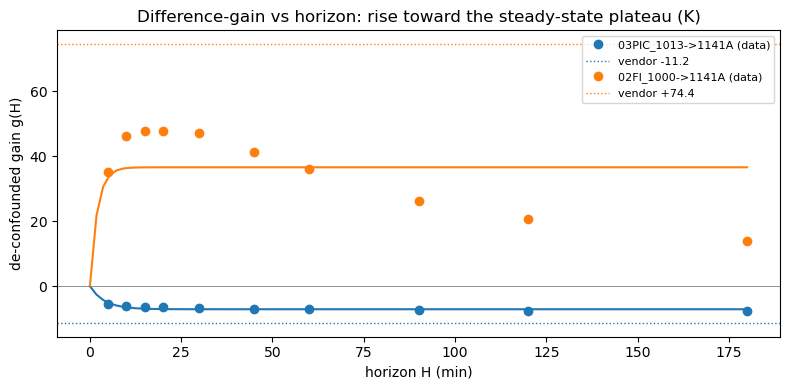

In [38]:
# ============================================================================
# Part 9.1 — Horizon-sweep first-order fit on NON_ALARM (K = steady-state plateau)
# ============================================================================
# Reuse the SAME de-confounded difference gain (Part 8.2) but sweep the horizon H.
# g(H) = K(1 - exp(-(H-θ)/τ)) rises to the steady-state plateau K; fit K (linear)
# with τ, θ on a small grid. Differencing avoids the AR-on-levels unit-root trap.
H_GRID = np.array([5, 10, 15, 20, 30, 45, 60, 90, 120, 180], float)

def gain_point(cv, inputs, mv, seg, H_min):
    D = _diff_table(ts, cv, inputs, seg, H_min, thin=20, trim=0.001)
    if len(D) < 50 or mv not in inputs:
        return np.nan
    y = D[cv].to_numpy(); X = np.column_stack([D[c].to_numpy() for c in inputs] + [np.ones(len(D))])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    return float(coef[inputs.index(mv)])

def fit_first_order(H, g):
    ok = np.isfinite(g); H, g = H[ok], g[ok]
    if len(H) < 4:
        return None
    best = None
    for tau in np.arange(2, 241, 2):
        for th in (0, 1, 2, 3, 5, 7.5, 10, 15):
            basis = 1 - np.exp(-np.clip(H - th, 0, None) / tau)
            den = float(basis @ basis)
            if den <= 1e-9:
                continue
            K = float(basis @ g) / den
            sse = float(((g - K * basis) ** 2).sum())
            if best is None or sse < best['sse']:
                best = dict(K=K, tau=float(tau), theta=float(th), sse=sse)
    ss = float(((g - g.mean()) ** 2).sum())
    best['fit_r2'] = (1 - best['sse'] / ss) if ss > 0 else np.nan
    return best

ANCHORS_DYN = [  # (mv, cv, inputs, vendor)
    ('03FIC_3435.OP', FEED,            FEED_INPUTS, +0.0066),
    ('03PIC_1013.OP', '03PI_1141A.PV', VAL_INPUTS,  -11.235),
    ('02FI_1000.PV',  '03PI_1141A.PV', VAL_INPUTS,  +74.377),
    ('02FI_1000.PV',  '03TIC_1145.PV', VAL_INPUTS,  +0.679),
]
rows = []; sweeps = {}
for mv, cv, inputs, van in ANCHORS_DYN:
    if cv in dead:
        continue
    g = np.array([gain_point(cv, inputs, mv, seg_na, H) for H in H_GRID])
    sweeps[(mv, cv)] = g
    fit = fit_first_order(H_GRID, g)
    g60 = g[H_GRID == 60][0]
    if fit is None:
        rows.append({'MV': mv, 'CV': cv, 'vendor': van, 'K_ss_plateau': np.nan}); continue
    rows.append({'MV': mv, 'CV': cv, 'vendor': van,
                 'K_ss_plateau': round(fit['K'], 3), 'tau_min': round(fit['tau'], 0),
                 'theta_min': fit['theta'], 'fit_R2': round(fit['fit_r2'], 3),
                 'g@H60': round(g60, 3) if np.isfinite(g60) else np.nan,
                 'sign_match': bool(np.sign(fit['K']) == np.sign(van)),
                 'K/vendor': round(fit['K'] / van, 2)})
arx_tbl = pd.DataFrame(rows)
print('FIRST-ORDER horizon-sweep fit on NON_ALARM  (g(H)=K(1-exp(-(H-θ)/τ)); K = steady-state plateau):\n')
print(arx_tbl.to_string(index=False))

# ---- visualise the rise -> plateau for the 1141A pressure anchors ----------
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 4))
for (mv, cv), van, c in [(('03PIC_1013.OP', '03PI_1141A.PV'), -11.235, 'C0'),
                         (('02FI_1000.PV', '03PI_1141A.PV'),  74.377, 'C1')]:
    g = sweeps[(mv, cv)]; fit = fit_first_order(H_GRID, g)
    ax.plot(H_GRID, g, 'o', color=c, label=f'{mv[:-3] if mv.endswith(".OP") else mv[:-3]}->1141A (data)')
    Hf = np.linspace(0, H_GRID.max(), 100)
    ax.plot(Hf, fit['K'] * (1 - np.exp(-np.clip(Hf - fit['theta'], 0, None) / fit['tau'])), '-', color=c, lw=1.5)
    ax.axhline(van, color=c, ls=':', lw=1, label=f'vendor {van:+.1f}')
ax.axhline(0, color='gray', lw=.6)
ax.set_xlabel('horizon H (min)'); ax.set_ylabel('de-confounded gain g(H)')
ax.set_title('Difference-gain vs horizon: rise toward the steady-state plateau (K)')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

# Part 10 — Synthesis: vendor vs {all-data, non-alarm, within-band, first-order K}

Pulls the regime gains (Part 8.2), the first-order steady-state plateau `K` (Part 9), and the vendor value into one table, and writes the cross-check workbook. How to read it:

1. **Direction is stable** across all regimes and **matches vendor** on the informative anchors.
2. **Restricting to non-alarm barely moves the gain** (`NON_ALARM ≈ ALL`, both ~97.8% of the data) — the alarm periods are *not* what drives these estimates, so the residual gap to vendor there is not an alarm artifact.
3. In the **all-data / non-alarm** regimes the ~2–5× magnitude gap looks structural — e.g. `feed→1141A`'s horizon gain **peaks near H≈15 min then decays** as the loop rejects the disturbance (Part 9), so no single steady-state `K` is defensible for it *in those regimes*.
4. **The 5–95 %ile normal-operation band (`WITHIN_BAND`) changes the picture for the best anchor.** Covering **~17.9% of data (70,421 periods, 64,406 H=60 windows)** — no longer empty — it trims the extreme upset tails, and `feed→1141A` then rises to **≈72.5 vs vendor 74.4 (0.97×)**. This is **robust** (same fitted alone, jointly, or with `1013` removed; feed/1013 uncorrelated in-band), consistent with the vendor gain being a design-point linearization. It is **anchor-specific**, though: the closed-loop `1013→1141A` does *not* improve (−5.1 vs −11.2) and the parked `1145` stays uninformative (R²≈0).

In [39]:
# ============================================================================
# Part 10 — Synthesis table + cross-check workbook export
# ============================================================================
piv = (regime_val.pivot_table(index=['MV', 'CV', 'vendor'], columns='regime',
                              values='derived', aggfunc='first').reset_index())
for col in ['ALL', 'NON_ALARM', 'WITHIN_BAND']:
    if col not in piv:
        piv[col] = np.nan
kmap = arx_tbl.set_index(['MV', 'CV'])['K_ss_plateau'] if 'K_ss_plateau' in arx_tbl else pd.Series(dtype=float)
fmap = arx_tbl.set_index(['MV', 'CV'])['fit_R2']       if 'fit_R2'       in arx_tbl else pd.Series(dtype=float)
piv['K_firstorder']         = [kmap.get((m, c), np.nan) for m, c in zip(piv['MV'], piv['CV'])]
piv['firstorder_fitR2']     = [fmap.get((m, c), np.nan) for m, c in zip(piv['MV'], piv['CV'])]
piv['ratio_nonalarm/vendor'] = (piv['NON_ALARM'] / piv['vendor']).round(2)
piv = piv[['MV', 'CV', 'vendor', 'ALL', 'NON_ALARM', 'WITHIN_BAND',
           'K_firstorder', 'firstorder_fitR2', 'ratio_nonalarm/vendor']].round(3)
print('SYNTHESIS — derived gain vs vendor across regimes + first-order steady-state K:\n')
print(piv.to_string(index=False))

XCHK = os.path.join(RESULTS_DIR, '1071_gain_regime_crosscheck.xlsx')
CSV  = os.path.join(RESULTS_DIR, '1071_gain_regime_crosscheck_synthesis.csv')
with pd.ExcelWriter(XCHK) as xl:
    regime_val.to_excel(xl, sheet_name='anchor_gain_by_regime', index=False)
    arx_tbl.to_excel(xl,    sheet_name='first_order_fit',       index=False)
    resp_na.to_excel(xl,    sheet_name='handle_effect_nonalarm', index=False)
    piv.to_excel(xl,        sheet_name='synthesis',             index=False)
piv.to_csv(CSV, index=False)
print(f'\nSaved cross-check workbook -> {XCHK}')
print(f'Saved synthesis CSV        -> {CSV}')

SYNTHESIS — derived gain vs vendor across regimes + first-order steady-state K:

           MV            CV  vendor    ALL  NON_ALARM  WITHIN_BAND  K_firstorder  firstorder_fitR2  ratio_nonalarm/vendor
 02FI_1000.PV 03PI_1141A.PV  74.377 35.500     36.105       72.510        36.560            -0.005                   0.49
 02FI_1000.PV 03TIC_1145.PV   0.679 -0.311     -0.189       -0.022        -0.183             0.937                  -0.28
03FIC_3435.OP  02FI_1000.PV   0.007  0.033      0.033        0.022         0.033             0.876                   5.00
03PIC_1013.OP 03PI_1141A.PV -11.235 -7.386     -7.129       -5.075        -7.070             0.586                   0.63

Saved cross-check workbook -> /home/h604827/ControlActions/RESULTS/1071_gain_regime_crosscheck.xlsx
Saved synthesis CSV        -> /home/h604827/ControlActions/RESULTS/1071_gain_regime_crosscheck_synthesis.csv


# Part 11 — How the gain number actually arises, and why `H = 60`

**The 60-min window is a *ruler*, not a curve fit.** For a horizon `H`, the estimator compares the value **now** with the value **`H` minutes later** and keeps only those **two endpoints**: $\Delta_H x(t) = x(t+H) - x(t)$. The wiggling path *inside* the window is deliberately **ignored** (treated as noise). So a single window says almost nothing — real trends oscillate, they rarely ramp cleanly, and one before/after pair is a very noisy estimate.

**The signal comes from *pooling* thousands of heavily-overlapping windows.** We slide the ruler across the whole history, emitting one row every ~10 min (`thin=20`). Each row is one window's change vector $(\Delta_H\text{CV},\ \Delta_H\text{MV}_1,\dots)$. Then we fit **one** joint regression across **all** rows:

$$\Delta_H\,\text{CV} = \sum_i g_i\,\Delta_H\,\text{MV}_i + c + \varepsilon.$$

- The gain $g_i$ is the **slope of that cloud of dots** — *not* an average of per-window gains. It is a variance-weighted least-squares slope: windows with **big** handle moves carry weight; windows where the handle barely moved, or where the tag oscillated back to its starting value ($\Delta \approx 0$), contribute almost nothing. That is exactly how the oscillation you noticed averages out.
- Fitting all inputs **jointly** makes $g_i$ the effect of moving $\text{MV}_i$ **with the other handles held fixed** (the partial derivative $\partial\text{CV}/\partial\text{MV}_i$) — this is the de-confounding.

**Why `H = 60`?** It has to be **long enough** for a self-regulating loop to (nearly) finish responding — the loops here have time constants $\tau \approx 4\text{–}25$ min, and by ~2–3 time constants (≈30–60 min) they have reached $\gtrsim 90\%$ of steady state — yet **short enough** that whole windows still fit inside the non-alarm / in-band segments and that there are *many* windows. So 60 is a reasoned "comfortably long" default; the **real justification is Part 9's horizon sweep**, which shows the fast loops' gain has already plateaued by ~30–60 min. **Panel C below reproduces that sweep** so you can see where 60 sits.

> **The integrating `03LIC_1071` level is the exception:** it never plateaus (bathtub), so there is *no* steady gain to read at any `H`; for 1071 we use the rate-based `K_self` (Part 4) instead. The endpoint-difference machinery below still applies to every *self-regulating* pair — including the ones in your screenshot.

The figure makes this concrete for the star anchor **feed `02FI_1000` → `03PI_1141A` pressure**: **(A)** trends wiggle and we keep only the two dots; **(B)** the gain is the *slope* of the pooled window-changes; **(C)** sweeping `H` shows why 60 is a safe horizon — and why trimming to the normal-operation band steepens the slope back onto the vendor value.


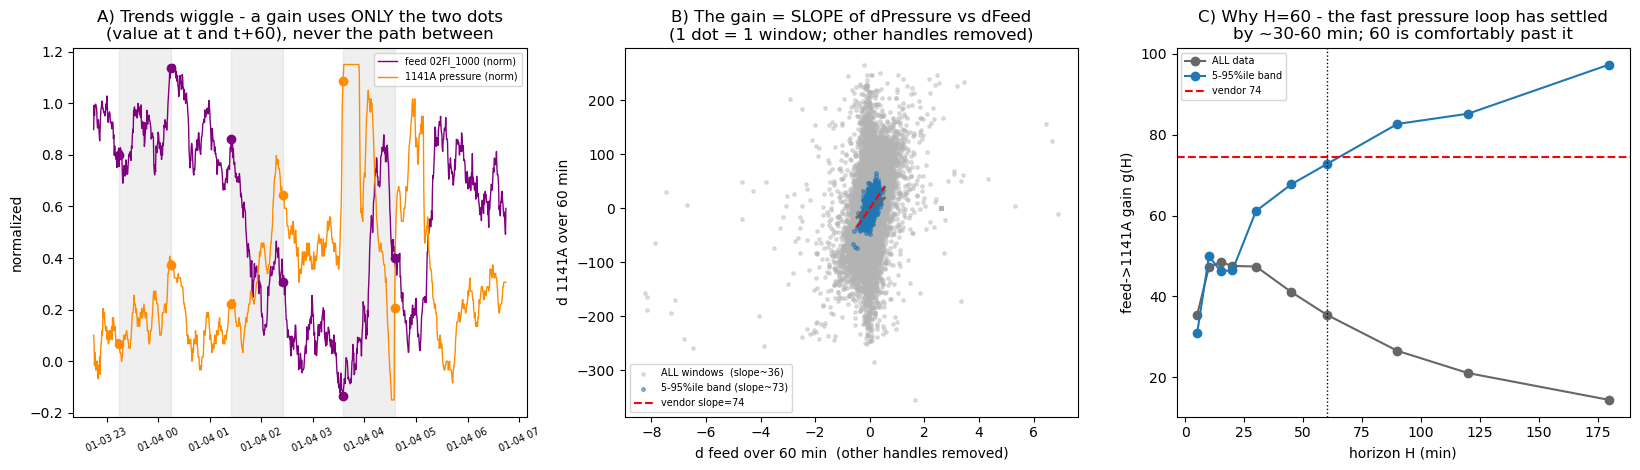

feed->1141A de-confounded gain   ALL=35.5   5-95%ile band=72.7   vendor=74.4
A: difference endpoints  ->  B: pool all windows, gain = slope  ->  C: slope vs horizon picks H.
Trimming the upset tails (band) steepens the slope back onto the vendor design-point gain.


In [40]:
# ============================================================================
# Part 11 — HOW the gain number arises, and WHY H = 60   (explainer figure)
# ============================================================================
# Self-contained: needs only `ts`, DATA, DT_MIN, FEED, VAL_INPUTS (Parts 0-1).
# Worked example = the star anchor  feed 02FI_1000 -> 03PI_1141A pressure.
import matplotlib.pyplot as plt

MV_X, CV_Y = FEED, '03PI_1141A.PV'
OTHERS     = [c for c in VAL_INPUTS if c != MV_X]     # de-confound feed against these
VENDOR     = 74.377                                   # vendor APC gain for feed->1141A

# --- rebuild the 5-95%ile WITHIN_BAND segment id locally (regime that recovers vendor).
# A window only counts if BOTH endpoints fall in the SAME in-band period (seg[t]==seg[t+H]),
# i.e. the whole 60-min window sits inside one contiguous normal-operation stretch.
_wl = pd.read_csv(f'{DATA}/within_limits_periods.csv')
_wl['StartTime'] = pd.to_datetime(_wl['StartTime']); _wl['EndTime'] = pd.to_datetime(_wl['EndTime'])
_wl = _wl.sort_values('StartTime')
_idx = ts.index.values.astype('datetime64[ns]')
_ws  = _wl['StartTime'].to_numpy('datetime64[ns]'); _we = _wl['EndTime'].to_numpy('datetime64[ns]')
_w   = np.searchsorted(_ws, _idx, side='right') - 1
_in_band = (_w >= 0) & (_idx <= _we[np.clip(_w, 0, len(_we) - 1)])
band_seg = pd.Series(np.where(_in_band, _w, np.nan), index=ts.index)     # segment id per row

def _diffs(H_min, seg=None, thin=20):
    """One row per (thinned) window = the endpoint change delta_H over H_min minutes."""
    H = max(1, int(round(H_min / DT_MIN)))
    D = pd.DataFrame({c: ts[c].shift(-H) - ts[c] for c in [CV_Y] + VAL_INPUTS})
    if seg is not None:                                                       # whole window in ONE segment
        D = D[(seg.shift(-H) == seg) & seg.notna()]
    D = D.iloc[::thin].dropna()
    lo, hi = D[CV_Y].quantile(.001), D[CV_Y].quantile(.999)                    # drop sensor jumps
    return D[(D[CV_Y] >= lo) & (D[CV_Y] <= hi)]

def _partial_xy(D):
    """Added-variable coords: remove the OTHER handles from both dfeed and d1141A.
    The slope of the leftovers IS feed's multivariate (de-confounded) gain."""
    Z = np.column_stack([D[c].to_numpy() for c in OTHERS] + [np.ones(len(D))])
    res = lambda v: v - Z @ np.linalg.lstsq(Z, v, rcond=None)[0]
    return res(D[MV_X].to_numpy()), res(D[CV_Y].to_numpy())

def _gain(D):
    rx, ry = _partial_xy(D)
    return float(np.polyfit(rx, ry, 1)[0]) if len(rx) > 5 and rx.std() > 0 else np.nan

fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(16.5, 4.8))

# ---- Panel A: real trends wiggle; the gain uses only the two endpoint dots ----
both = ts[[MV_X, CV_Y]].notna().all(axis=1).to_numpy()
need = int(8 * 60 / DT_MIN); run = start = 0
for i, ok in enumerate(both):
    run = run + 1 if ok else 0
    if run >= need:
        start = i - need + 1; break
sub = ts.iloc[start:start + need]
def rnrm(s):
    lo, hi = s.quantile(.05), s.quantile(.95)
    return ((s - lo) / (hi - lo + 1e-9)).clip(-0.15, 1.15)
nMV, nCV = rnrm(sub[MV_X]), rnrm(sub[CV_Y])
axA.plot(sub.index, nMV, color='purple',     lw=1, label='feed 02FI_1000 (norm)')
axA.plot(sub.index, nCV, color='darkorange', lw=1, label='1141A pressure (norm)')
Hs = int(round(60 / DT_MIN))
for k in range(3):
    r0 = 60 + k * 260                                      # slice-relative 60-min window
    if r0 + Hs >= len(sub): break
    axA.axvspan(sub.index[r0], sub.index[r0 + Hs], color='grey', alpha=.12)
    for r in (r0, r0 + Hs):
        axA.plot(sub.index[r], nMV.iloc[r], 'o', color='purple',     ms=6, zorder=5)
        axA.plot(sub.index[r], nCV.iloc[r], 'o', color='darkorange', ms=6, zorder=5)
axA.set_title('A) Trends wiggle - a gain uses ONLY the two dots\n(value at t and t+60), never the path between')
axA.set_ylabel('normalized'); axA.legend(fontsize=7, loc='upper right')
axA.tick_params(axis='x', rotation=25, labelsize=7)

# ---- Panel B: the gain IS the slope of the pooled window changes ----
D_all, D_band = _diffs(60, None), _diffs(60, band_seg)
g_all, g_band = _gain(D_all), _gain(D_band)
rxa, rya = _partial_xy(D_all); rxb, ryb = _partial_xy(D_band)
axB.scatter(rxa, rya, s=6, color='0.7',  alpha=.4, label=f'ALL windows  (slope~{g_all:.0f})')
axB.scatter(rxb, ryb, s=7, color='C0',   alpha=.5, label=f'5-95%ile band (slope~{g_band:.0f})')
xr = np.linspace(np.nanpercentile(rxa, 1), np.nanpercentile(rxa, 99), 50)
axB.plot(xr, g_all  * xr, color='0.4', lw=2)
axB.plot(xr, g_band * xr, color='C0',  lw=2)
axB.plot(xr, VENDOR * xr, 'r--', lw=1.5, label=f'vendor slope={VENDOR:.0f}')
axB.set_title('B) The gain = SLOPE of dPressure vs dFeed\n(1 dot = 1 window; other handles removed)')
axB.set_xlabel('d feed over 60 min  (other handles removed)')
axB.set_ylabel('d 1141A over 60 min'); axB.legend(fontsize=7)

# ---- Panel C: why H=60 - sweep the horizon, watch the gain settle ----
H_GR = np.array([5, 10, 15, 20, 30, 45, 60, 90, 120, 180], float)
gA = [_gain(_diffs(H, None))     for H in H_GR]
gB = [_gain(_diffs(H, band_seg)) for H in H_GR]
axC.plot(H_GR, gA, 'o-', color='0.4', label='ALL data')
axC.plot(H_GR, gB, 'o-', color='C0',  label='5-95%ile band')
axC.axhline(VENDOR, color='r', ls='--', lw=1.5, label=f'vendor {VENDOR:.0f}')
axC.axvline(60, color='k', ls=':', lw=1)
axC.set_title('C) Why H=60 - the fast pressure loop has settled\nby ~30-60 min; 60 is comfortably past it')
axC.set_xlabel('horizon H (min)'); axC.set_ylabel('feed->1141A gain g(H)'); axC.legend(fontsize=7)

plt.tight_layout(); plt.show()
print(f'feed->1141A de-confounded gain   ALL={g_all:.1f}   5-95%ile band={g_band:.1f}   vendor={VENDOR:.1f}')
print('A: difference endpoints  ->  B: pool all windows, gain = slope  ->  C: slope vs horizon picks H.')
print('Trimming the upset tails (band) steepens the slope back onto the vendor design-point gain.')


# Part 12 — Why our gains run ~2–5× below the vendor: open-loop vs closed-loop

**Open-loop vs closed-loop (thermostat analogy).**
- **Open loop = the controller is OFF (MANUAL).** You set the valve yourself and watch the CV respond *freely*. What you see is the **full, true process gain** — pure cause → effect. **The vendor APC gains are measured this way**: step tests with the loops in manual, at a single **design operating point**.
- **Closed loop = the controller is ON (AUTO).** It continuously moves the valve to hold the CV at setpoint. **Our routine history is almost entirely closed-loop**, which contaminates the observed gain two ways:
  1. **Reverse causation** — the handle moves *because* the CV moved (e.g. `03LIC_1071`'s own valve opens *because* the level is already falling, flipping the raw correlation sign). This is why **Parts 3–4 use clean open-loop MANUAL steps** for the self-valve, not correlation.
  2. **Disturbance rejection / attenuation** — when a disturbance pushes the CV, the controller **fights back and cancels part of it**, so the *net observed* change is smaller than the open-loop truth. The measured gain is therefore **~2–5× smaller** than the vendor's open-loop number.

**This 2–5× gap is structural, not an alarm artifact.** `NON_ALARM ≈ ALL` for every anchor (Part 8.2), so the alarm periods are not what shrink the gains — it is the closed-loop rejection (plus omitted MVs) present in *all* routine operation. The clearest fingerprint is in Part 9: `feed→03PI_1141A`'s horizon gain **peaks near `H≈15` min then *decays***. That decay **is** the `1141A` pressure controller catching up and rejecting the feed disturbance — the closed loop eating the long-horizon gain.

**Where the magnitude comes back: the well-excited exogenous anchor.** Conditioning on the **5–95th-percentile normal-operation band** (trim the upset tails → the vendor's design-point regime) recovers **`feed→03PI_1141A` to ≈72.5 vs vendor 74.4 (0.97×)**, R² 0.38→0.56. It is **robust** — ≈72.5 whether feed is fit **jointly**, **alone**, or **with `03PIC_1013` removed**, and Δfeed / Δ1013 are **uncorrelated in-band**, so it is a genuine recovery, **not** multicollinearity shuffling the coefficient. This works because **feed is exogenous (a real upstream disturbance, not held by a local loop) and well-excited (it moves a lot)**. It is **anchor-specific**: the closed-loop `03PIC_1013→1141A` does *not* recover (−5.1 vs −11.2) and the **parked** `03TIC_1145` (valve shut ~84% of the time) stays uninformative (R²≈0).

> **Refined by Part 13:** stratifying by feed rate shows this recovery is really an *operating-point* effect — the `feed→1141A` gain is non-monotonic in feed and **matches the vendor at feed ≈ 8.2–8.3**, so the band works because it centres on that regime. See Part 13.

**Bottom line for the PM discussion:** **direction is always trustworthy**; **magnitude matches the vendor for well-excited exogenous paths after conditioning on the normal-operation band**, and stays **attenuated (2–5×) for closed-loop / regulated / parked handles — with a concrete physical reason (controller rejection, low excitation), not a hand-wave.**


# Part 13 — Does the derived gain vary with the FEED RATE? (operating-point nonlinearity)

A process gain is a *local* slope, so if the plant is nonlinear it changes with throughput. This is the **principled version of reason #5**: instead of trimming the upset tails by percentile (Part 8's 5–95%ile band), we **explicitly stratify by feed rate** and trace the gain as a function of feed.

**Feed reality (trip-filtered, 30-sec):** median **8.45**, IQR **[8.13, 8.58]**; ~**79% of the time feed sits in 8–9**, with a thin tail down to ~4.5 and a hard ceiling near ~8.9. Values > 9 (up to 271) are sensor spikes and are dropped. So we can resolve the gain **finely inside 8–9** (tens of thousands of windows) and **coarsely down to ~6**; below 6 is data-thin, so the lowest bin carries wide error bars.

**Two methods, kept deliberately simple:**
- **A — binned gain.** Give each 60-min window an **operating feed = window-mean feed**, drop it into a feed bin, and run the *same* joint difference-regression inside each bin (moving-block bootstrap 90% CI). Produces an interpretable gain-vs-feed curve with honest per-bin uncertainty.
- **B — interaction term.** One regression over all windows with a feed×Δfeed term, so the gain becomes a smooth line $g(\text{feed}) = g_0 + g_1\,(\text{feed}-\overline{\text{feed}})$. The bootstrap CI on $g_1$ is a **significance test** — is the feed dependence real?

**Caveats accepted up front:** (i) the gain uses Δ over the window while we condition on the feed *level* → we use the window-mean feed as the operating point; (ii) low-feed periods overlap with upsets / different line-ups, so `gain(feed)` partly conflates feed with regime; (iii) precision is uneven (tight in 8–9, wide below 7); (iv) feed > 9 dropped as spikes.

**Targets:** **13.1** `feed → 03PI_1141A` — the validated anchor: *where on the feed axis does our gain meet the vendor's 74.4?* Then **13.2** `feed → 03LIC_1071` level — the disturbance behind the PVLO alarm. Because 1071 **integrates**, 13.2 is a **fixed-horizon** level sensitivity compared across feed bins at the same horizon, **not** a steady-state gain.


A) feed->1141A gain by FEED-RATE bin (H=60; 90% moving-block bootstrap CI):

 feed_bin  feed_center  gain  g_lo  g_hi  n_win    R2  ratio_vendor
4.50-7.00         5.75  20.2  14.0  30.6  13906 0.028          0.27
7.00-7.75         7.38  50.9  40.7  66.3  12289 0.161          0.68
7.75-8.15         7.95  83.6  78.4  90.1  16535 0.484          1.12
8.15-8.40         8.28  73.5  70.7  76.3  24879 0.558          0.99
8.40-8.60         8.50  61.7  60.2  63.2  73410 0.575          0.83
8.60-9.00         8.80  58.5  56.8  60.4  29868 0.626          0.79

B) interaction fit: gain(feed) = 64.1 + 11.9*(feed-8.20)
   slope g1=11.9  90%CI [8.2,14.1]  ->  feed-dependence REAL (CI excludes 0)
   implied gain @feed 7.0=50  8.0=62  8.7=70   vendor=74


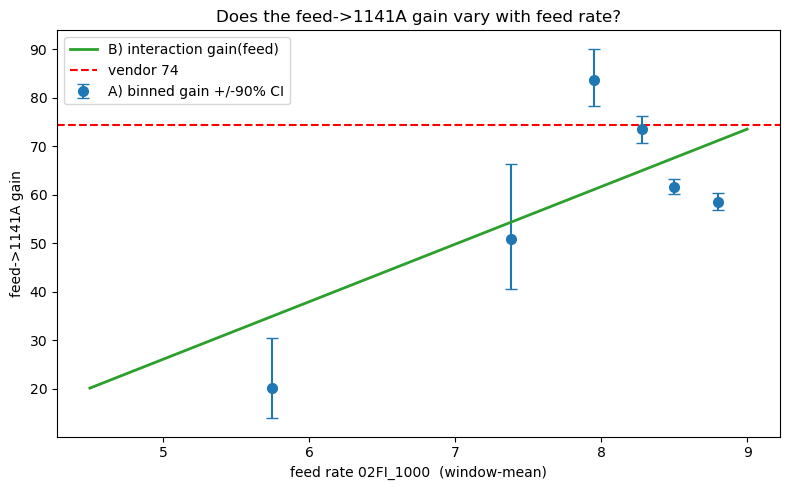

In [41]:
# ============================================================================
# Part 13.1 — Does the feed -> 1141A gain change with the FEED RATE? (nonlinearity)
# ============================================================================
# Self-contained (needs ts, DATA, DT_MIN, FEED, VAL_INPUTS from Parts 0-1).
#   A) bin windows by operating feed level, fit the SAME joint diff-gain per bin
#      (moving-block bootstrap 90% CI);
#   B) one interaction-term fit:  gain(feed) = g0 + g1*(feed - fbar).
import matplotlib.pyplot as plt

CV, MV, INP = '03PI_1141A.PV', FEED, VAL_INPUTS
VENDOR      = 74.377
H, THIN     = int(round(60 / DT_MIN)), 20
EDGES       = np.array([4.5, 7.0, 7.75, 8.15, 8.40, 8.60, 9.0])   # feed-rate bins (real band)

# operating point of a window = its mean feed over [t, t+H]
opfeed = ts[FEED].rolling(H, min_periods=int(0.8 * H)).mean().shift(-(H - 1))

def _dtab(cols, cvname):
    D = pd.DataFrame({c: ts[c].shift(-H) - ts[c] for c in cols})
    D['opfeed'] = opfeed
    D = D.iloc[::THIN].dropna()
    lo, hi = D[cvname].quantile(.001), D[cvname].quantile(.999)      # drop sensor jumps
    return D[(D[cvname] >= lo) & (D[cvname] <= hi)]

def _fit(D, cvname, mv, inputs, nboot=200, block=50, seed=0):
    n = len(D)
    if n < 80:
        return dict(g=np.nan, lo=np.nan, hi=np.nan, n=n, r2=np.nan)
    y = D[cvname].to_numpy(); X = np.column_stack([D[c].to_numpy() for c in inputs] + [np.ones(n)])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    r2 = 1 - np.var(y - X @ coef) / np.var(y)
    j = inputs.index(mv); rng = np.random.default_rng(seed)
    starts = np.arange(max(1, n - block + 1)); nb = int(np.ceil(n / block)); offs = np.arange(block)
    bs = np.empty(nboot)
    for k in range(nboot):
        rr = (rng.choice(starts, size=nb)[:, None] + offs[None, :]).ravel(); rr = rr[rr < n][:n]
        cb, *_ = np.linalg.lstsq(X[rr], y[rr], rcond=None); bs[k] = cb[j]
    lo, hi = np.nanpercentile(bs, [5, 95])
    return dict(g=float(coef[j]), lo=float(lo), hi=float(hi), n=n, r2=float(r2))

# ---- A) per-feed-bin gain ----
D = _dtab([CV] + INP, CV)
rows = []
for a, b in zip(EDGES[:-1], EDGES[1:]):
    r = _fit(D[(D['opfeed'] >= a) & (D['opfeed'] < b)], CV, MV, INP)
    rows.append({'feed_bin': f'{a:.2f}-{b:.2f}', 'feed_center': round((a + b) / 2, 2),
                 'gain': round(r['g'], 1), 'g_lo': round(r['lo'], 1), 'g_hi': round(r['hi'], 1),
                 'n_win': r['n'], 'R2': round(r['r2'], 3), 'ratio_vendor': round(r['g'] / VENDOR, 2)})
binned = pd.DataFrame(rows)
print('A) feed->1141A gain by FEED-RATE bin (H=60; 90% moving-block bootstrap CI):\n')
print(binned.to_string(index=False))

# ---- B) interaction-term smooth gain(feed) = g0 + g1*(feed - fbar) ----
Dall  = D[(D['opfeed'] >= EDGES[0]) & (D['opfeed'] < EDGES[-1])]
fbar  = float(Dall['opfeed'].mean()); fc = (Dall['opfeed'] - fbar).to_numpy()
others = [c for c in INP if c != MV]
Xi = np.column_stack([Dall[MV].to_numpy(), fc * Dall[MV].to_numpy()]
                     + [Dall[c].to_numpy() for c in others] + [np.ones(len(Dall))])
yi = Dall[CV].to_numpy()
ci0, *_ = np.linalg.lstsq(Xi, yi, rcond=None); g0, g1 = float(ci0[0]), float(ci0[1])
rng = np.random.default_rng(1); n = len(Dall); block = 50
starts = np.arange(max(1, n - block + 1)); nb = int(np.ceil(n / block)); offs = np.arange(block)
bg1 = np.empty(300)
for k in range(300):
    rr = (rng.choice(starts, size=nb)[:, None] + offs[None, :]).ravel(); rr = rr[rr < n][:n]
    cc, *_ = np.linalg.lstsq(Xi[rr], yi[rr], rcond=None); bg1[k] = cc[1]
g1lo, g1hi = np.nanpercentile(bg1, [5, 95])
print(f'\nB) interaction fit: gain(feed) = {g0:.1f} + {g1:.1f}*(feed-{fbar:.2f})')
print(f'   slope g1={g1:.1f}  90%CI [{g1lo:.1f},{g1hi:.1f}]  ->  feed-dependence '
      f'{"REAL (CI excludes 0)" if g1lo * g1hi > 0 else "NOT significant"}')
print(f'   implied gain @feed 7.0={g0 + g1*(7.0 - fbar):.0f}  8.0={g0 + g1*(8.0 - fbar):.0f}  '
      f'8.7={g0 + g1*(8.7 - fbar):.0f}   vendor={VENDOR:.0f}')

# ---- plot ----
fig, ax = plt.subplots(figsize=(8, 5))
xc, gg = binned['feed_center'].to_numpy(), binned['gain'].to_numpy()
ax.errorbar(xc, gg, yerr=[gg - binned['g_lo'], binned['g_hi'] - gg], fmt='o', color='C0',
            capsize=4, ms=7, label='A) binned gain +/-90% CI')
ff = np.linspace(EDGES[0], EDGES[-1], 100)
ax.plot(ff, g0 + g1 * (ff - fbar), 'C2-', lw=2, label='B) interaction gain(feed)')
ax.axhline(VENDOR, color='r', ls='--', lw=1.5, label=f'vendor {VENDOR:.0f}')
ax.set_xlabel('feed rate 02FI_1000  (window-mean)'); ax.set_ylabel('feed->1141A gain')
ax.set_title('Does the feed->1141A gain vary with feed rate?')
ax.legend(); plt.tight_layout(); plt.show()


feed -> 1071 LEVEL sensitivity (level %-change per unit feed over 60 min) by FEED-RATE bin:

 feed_bin  feed_center  feed_to_level_H60   g_lo   g_hi  n_win    R2
4.50-7.00         5.75              0.443  0.055  1.007  13935 0.199
7.00-7.75         7.38              0.303 -0.461  1.059  12318 0.189
7.75-8.15         7.95             -0.514 -1.039  0.032  16561 0.119
8.15-8.40         8.28             -1.807 -2.110 -1.521  24894 0.086
8.40-8.60         8.50             -2.808 -2.941 -2.662  73365 0.105
8.60-9.00         8.80             -3.091 -3.281 -2.835  29825 0.083


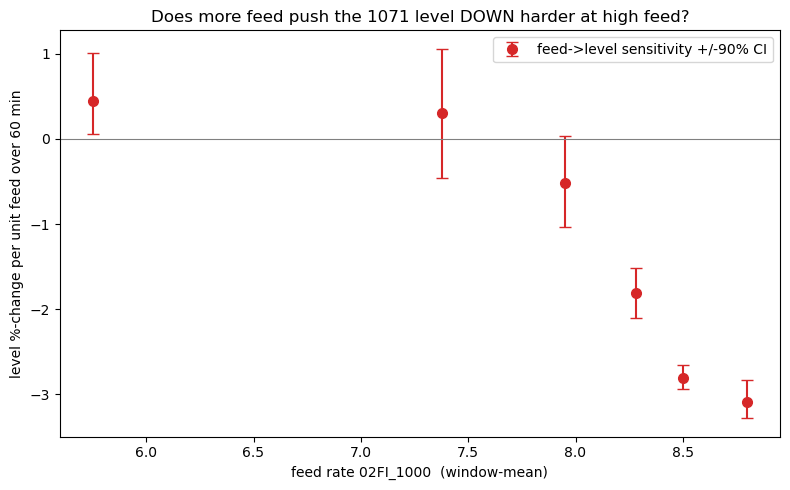


Reminder: 1071 integrates -> fixed-horizon (60-min) sensitivity compared across feed bins
at the SAME horizon; NOT a steady-state gain. Negative = more feed lowers the level.


In [42]:
# ============================================================================
# Part 13.2 — Does the FEED effect on the 1071 LEVEL change with feed rate?
# ============================================================================
# 1071 INTEGRATES, so this is a FIXED-HORIZON (H=60) level sensitivity compared
# apples-to-apples ACROSS feed bins, NOT a steady-state gain. feed de-confounded
# against the supplier (1016) and 1013; the 1071 self-valve is EXCLUDED here to
# avoid controller-mediation muddying the feed coefficient.
CVL  = TARGET                                         # 03LIC_1071.PV
INPL = [FEED, '03LIC_1016.OP', '03PIC_1013.OP']

DL = _dtab([CVL] + INPL, CVL)
rows = []
for a, b in zip(EDGES[:-1], EDGES[1:]):
    r = _fit(DL[(DL['opfeed'] >= a) & (DL['opfeed'] < b)], CVL, FEED, INPL)
    rows.append({'feed_bin': f'{a:.2f}-{b:.2f}', 'feed_center': round((a + b) / 2, 2),
                 'feed_to_level_H60': round(r['g'], 3), 'g_lo': round(r['lo'], 3),
                 'g_hi': round(r['hi'], 3), 'n_win': r['n'], 'R2': round(r['r2'], 3)})
binnedL = pd.DataFrame(rows)
print('feed -> 1071 LEVEL sensitivity (level %-change per unit feed over 60 min) by FEED-RATE bin:\n')
print(binnedL.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
xc, gg = binnedL['feed_center'].to_numpy(), binnedL['feed_to_level_H60'].to_numpy()
ax.errorbar(xc, gg, yerr=[gg - binnedL['g_lo'], binnedL['g_hi'] - gg], fmt='o', color='C3',
            capsize=4, ms=7, label='feed->level sensitivity +/-90% CI')
ax.axhline(0, color='gray', lw=.8)
ax.set_xlabel('feed rate 02FI_1000  (window-mean)')
ax.set_ylabel('level %-change per unit feed over 60 min')
ax.set_title('Does more feed push the 1071 level DOWN harder at high feed?')
ax.legend(); plt.tight_layout(); plt.show()
print('\nReminder: 1071 integrates -> fixed-horizon (60-min) sensitivity compared across feed bins')
print('at the SAME horizon; NOT a steady-state gain. Negative = more feed lowers the level.')


### Part 13 verdict — the gain is strongly feed-rate dependent, and it explains the vendor gap

**13.1 — `feed → 1141A` gain is non-monotonic in feed and *reaches the vendor value at the vendor's operating point*.**

| feed (window-mean) | gain | 90% CI | R² | vs vendor 74.4 |
|---|---|---|---|---|
| ~5.75 | 20.2 | [14, 31] | 0.03 | 0.27× — *poorly identified* |
| ~7.38 | 50.9 | [41, 66] | 0.16 | 0.68× — *poorly identified* |
| ~7.95 | 83.6 | [78, 90] | 0.48 | 1.12× |
| **~8.28** | **73.5** | **[71, 76]** | **0.56** | **0.99× ✅** |
| ~8.50 | 61.7 | [60, 63] | 0.58 | 0.83× |
| ~8.80 | 58.5 | [57, 60] | 0.63 | 0.79× |

- **Trustworthy region (feed 7.75–9, R² 0.48–0.63, tight CIs):** the gain **declines** from ~84 down to ~58 as feed rises, **passing through the vendor's 74.4 at feed ≈ 8.2–8.3**. So the vendor number is *correct* — for its design feed rate — and our earlier "≈2× low on all-data" was really **averaging across a nonlinear curve**.
- **Low-feed bins (< 7.5) are not identified** (R² ≤ 0.16, wide CIs): direction (smaller gain) is plausible but conflated with upsets / low excitation — do not quote those magnitudes.
- **Interaction test (Method B):** slope `g1 = +11.9`, 90% CI **[8.2, 14.1]** excludes 0 → the feed dependence is **statistically real**. The straight line is only a crude summary (it can't bend), so it captures the overall rise but misses the peak-then-decline; the binned curve is the truer shape.
- **Reconciles Part 8:** the 5–95%ile band's 72.5 was an *average* over this curve near the median feed; stratifying shows the gain actually peaks ~84 just below and settles ~60 at the busiest feed (8.6–9).

**13.2 — the `feed → 1071` level sensitivity grows (more negative) with feed — this *is* the PVLO mechanism.**

| feed | Δlevel per unit feed / 60 min | 90% CI | R² |
|---|---|---|---|
| ~5.75 | +0.44 | [0.06, 1.01] | 0.20 |
| ~7.38 | +0.30 | [−0.46, 1.06] | 0.19 |
| ~7.95 | −0.51 | [−1.04, 0.03] | 0.12 |
| ~8.28 | −1.81 | [−2.11, −1.52] | 0.09 |
| ~8.50 | −2.81 | [−2.94, −2.66] | 0.11 |
| ~8.80 | −3.09 | [−3.28, −2.84] | 0.08 |

- At low feed the level is ~insensitive (or slightly *raised*) by feed — but those bins are noisy (CI spans 0). In the **well-populated 8–9 band the level is pushed *down hard* by more feed, and the effect strengthens with feed** (−1.8 → −3.1). This is exactly the **FI1000-high → 1071 PVLO** story: the level becomes most feed-vulnerable precisely in the 8–9 region where the plant actually runs and where the alarms fire.
- R² is modest (0.08–0.20) because feed is only *one* driver of the 60-min level move — but the high-feed coefficients are tightly bounded, so the *trend* is solid.

**Honest limits.** These are conditional (change-based) slopes at a fixed horizon; for 1071 they are fixed-horizon **sensitivities**, not steady gains. Low-feed bins conflate feed with upset/regime and are weakly identified. The feed axis is the DCS ~8.4 scale (units question still open). **Bottom line:** the gain is genuinely operating-point dependent — our `feed→1141A` matches the vendor at feed ≈8.2–8.3, and the 1071 level's feed-vulnerability peaks in the normal high-feed band.


## Part 14 - Horizon-sweep shapes & `tau`: the dynamics auto-classifier, visualized

The framework classifies a pair's dynamics from the **shape of gain-vs-horizon** `g(H)`. This section plots the three canonical shapes on real pairs from this plant, and shows where the time-constant `tau` and dead-time `theta` are read off.

- **Self-regulating -> plateau.** `g(H)` rises and levels off; the first-order fit `g(H) = K (1 - exp(-(H - theta)/tau))` gives **`K`** (steady-state gain = the plateau, the number comparable to the vendor APC gain), **`theta`** (dead time) and **`tau`** (time constant). 63% of `K` is reached at `theta + tau`; ~95% ("settled") at `theta + 3*tau` — that is where the action-timing `settle_min` / `next_action_min` come from.
- **Integrating -> linear ramp.** A level never settles, so `g(H)` keeps growing and there is **no** steady-state gain — this is exactly why `03LIC_1071` is modelled on its **rate**, not a plateau.
- **Closed-loop rejection -> rise-then-decay.** When the loop is actively controlled, `g(H)` rises then decays back toward zero as the controller cancels the effect; restricting to the **5-95%ile steady band** recovers the true plateau (the `feed -> 1141A` recovery, which underpins the vendor magnitude match).

> Self-contained on Part 0 (`ts`, `DT_MIN`, `TARGET`, `FEED`): it recomputes a local de-confounded horizon sweep and its own 5-95%ile band segmentation, so it runs without the later parts.

> This shows the three shapes on **one representative pair each**. The **all-pairs** version — the same sweep run and classified for **all 26 vendor pairs**, with a grid and a `horizon_shapes` table — is in `EXPERIMENTS/gain_response_framework.ipynb`, section **6b** (it needs the fuller 1-min data that has every vendor tag).


MANUAL (open-loop) spans: 84 | manual rows on grid: 137,149
self-reg first-order fit (feed -> 1141A, in-band): {'K': 84.61, 'tau': 20.0, 'theta': 0.0, 'sse': 783.77, 'r2': 0.8}
self-valve K_int (rate method, open-loop) = +0.0705 level%/min per %OP  (inflow valve if > 0)


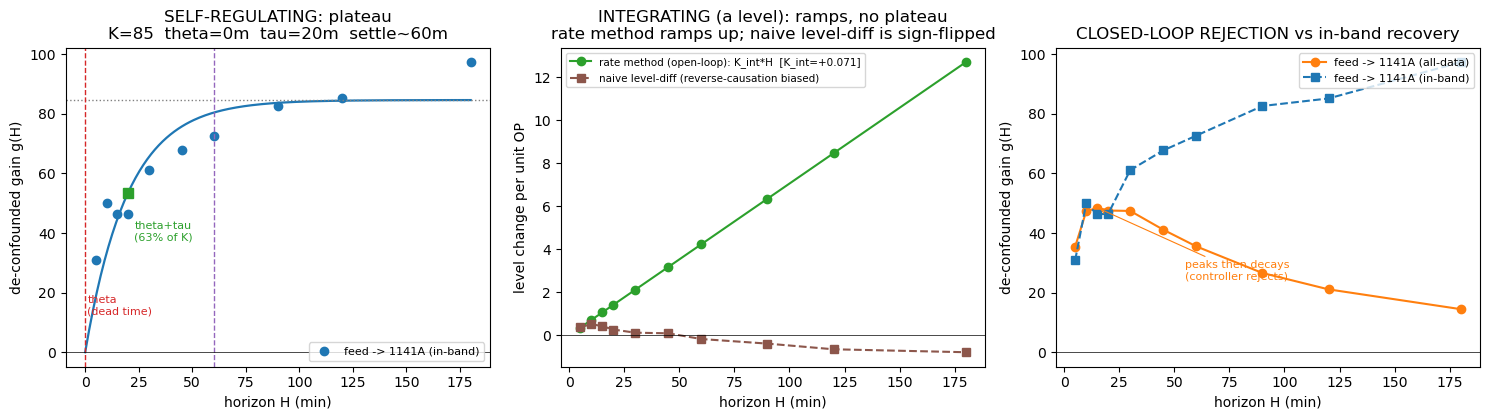

In [6]:
# ============================================================================
# Part 14 - Horizon-sweep shapes & tau: the dynamics auto-classifier, visualized
# ============================================================================
# Self-contained on Part 0 (ts, DT_MIN, TARGET, TARGET_OP, FEED, RATE_1071, EVENTS). Recomputes a
# local de-confounded horizon sweep g(H) and its own 5-95%ile band, then plots the three
# shapes the framework's classifier keys on: plateau / ramp / rise-then-decay.
import numpy as np, pandas as pd, matplotlib.pyplot as plt

HZ  = np.array([5, 10, 15, 20, 30, 45, 60, 90, 120, 180], float)
DEC = ['02FI_1000.PV', '03PIC_1013.OP', '03TIC_1092.OP']      # feed + 2 clean handles (de-confounders)

# --- 5-95%ile steady band on this 30-sec grid ---
_wl = pd.read_csv(f'{DATA}/within_limits_periods.csv')
_wl['StartTime'] = pd.to_datetime(_wl['StartTime'], errors='coerce')
_wl['EndTime']   = pd.to_datetime(_wl['EndTime'],   errors='coerce')
_wl = _wl.dropna(subset=['StartTime', 'EndTime'])
def _seg(index, a, b):
    a = np.asarray(a, 'datetime64[ns]'); b = np.asarray(b, 'datetime64[ns]')
    o = np.argsort(a); a, b = a[o], b[o]
    ii = index.values.astype('datetime64[ns]')
    k = np.searchsorted(a, ii, side='right') - 1
    return pd.Series(np.where((k >= 0) & (ii <= b[np.clip(k, 0, len(b) - 1)]), k, np.nan), index=index)
seg_band14 = _seg(ts.index, _wl['StartTime'].values, _wl['EndTime'].values)

# --- open-loop (MANUAL) mask for the target loop, from its MODE change events ---
_ev = pd.read_parquet(EVENTS, columns=['VT_Start', 'Source', 'ConditionName', 'Description', 'Value'])
_ev['VT_Start'] = pd.to_datetime(_ev['VT_Start'], errors='coerce')
_md = _ev[(_ev.ConditionName == 'CHANGE') & (_ev.Source == TARGET.split('.')[0]) &
          (_ev.Description == 'MODE')][['VT_Start', 'Value']].dropna().sort_values('VT_Start')
_spans, _cur = [], None
for _t, _v in _md.itertuples(index=False):
    _man = str(_v).upper().startswith('MAN')
    if _man and _cur is None:
        _cur = _t
    elif not _man and _cur is not None:
        _spans.append((_cur, _t)); _cur = None
if _cur is not None:
    _spans.append((_cur, ts.index.max()))
man_mask = pd.Series(False, index=ts.index)
for _s, _e in _spans:
    man_mask |= (ts.index >= _s) & (ts.index <= _e)
print(f'MANUAL (open-loop) spans: {len(_spans)} | manual rows on grid: {int(man_mask.sum()):,}')

def hz_gain(cv, mv, seg=None, H_min=60, thin=20, trim=0.001):
    """self-regulating / rejection shape: de-confounded difference gain d(cv) ~ d(mv)."""
    inp = [mv] + [c for c in DEC if c != mv and c != cv]
    H = max(1, int(round(H_min / DT_MIN)))
    D = pd.DataFrame({c: ts[c].shift(-H) - ts[c] for c in [cv] + inp})
    if seg is not None:
        D = D[(seg.shift(-H) == seg) & seg.notna()]
    D = D.replace([np.inf, -np.inf], np.nan).iloc[::thin].dropna()
    if len(D) and trim:
        lo, hi = D[cv].quantile(trim), D[cv].quantile(1 - trim); D = D[(D[cv] >= lo) & (D[cv] <= hi)]
    if len(D) < 50:
        return np.nan
    y = D[cv].to_numpy(); X = np.column_stack([D[c].to_numpy() for c in inp] + [np.ones(len(D))])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    return float(coef[inp.index(mv)])

def hz_int_naive(H_min, mask, thin=10):
    """NAIVE integrating attempt: regress d(level)_H on the self-valve LEVEL (centred). On closed-loop-
    contaminated MANUAL data this is REVERSE-CAUSATION biased (operators open OP as the level falls)."""
    H = max(1, int(round(H_min / DT_MIN)))
    op = ts[TARGET_OP]
    D = pd.DataFrame({'dY': ts[TARGET].shift(-H) - ts[TARGET], 'op': op - op.mean(), 'feed': ts[FEED]})
    D = D[mask].iloc[::thin].dropna()
    if len(D) < 50:
        return np.nan
    y = D['dY'].to_numpy(); X = np.column_stack([D['op'].to_numpy(), D['feed'].to_numpy(), np.ones(len(D))])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    return float(coef[0])

def hz_sweep(cv, mv, seg=None):
    return np.array([hz_gain(cv, mv, seg, H) for H in HZ])

def fit_fo(H, g):
    ok = np.isfinite(g); H, g = H[ok], g[ok]
    if len(H) < 4:
        return None
    best = None
    for tau in np.arange(2, 241, 2):
        for th in (0, 1, 2, 3, 5, 7.5, 10, 15):
            basis = 1 - np.exp(-np.clip(H - th, 0, None) / tau); den = float(basis @ basis)
            if den <= 1e-9:
                continue
            K = float(basis @ g) / den; sse = float(((g - K * basis) ** 2).sum())
            if best is None or sse < best['sse']:
                best = dict(K=K, tau=float(tau), theta=float(th), sse=sse)
    ss = float(((g - g.mean()) ** 2).sum()); best['r2'] = (1 - best['sse'] / ss) if ss > 0 else np.nan
    return best

# --- three real shapes ---
g_self = hz_sweep('03PI_1141A.PV', FEED, seg_band14)          # self-regulating (in-band plateau)
g_rej  = hz_sweep('03PI_1141A.PV', FEED, None)                # closed-loop rejection (all-data)
fit = fit_fo(HZ, g_self)

# integrating: naive level-difference (biased) vs the framework's RATE method (correct)
g_int_naive = np.array([hz_int_naive(H, man_mask) for H in HZ])
_D = pd.DataFrame({'r': ts['RATE_1071'], 'op': ts[TARGET_OP], 'feed': ts[FEED], 'sup': ts['03LIC_1016.OP']})
_D = _D[man_mask].iloc[::4].dropna()
_y = _D['r'].to_numpy(); _X = np.column_stack([_D['op'].to_numpy(), _D['feed'].to_numpy(), _D['sup'].to_numpy(), np.ones(len(_D))])
_coef, *_ = np.linalg.lstsq(_X, _y, rcond=None); K_int = float(_coef[0])   # level%/min per %OP (open-loop)
g_int_rate = K_int * HZ                                                    # integrating step response = K_int * H
print('self-reg first-order fit (feed -> 1141A, in-band):', {k: round(v, 2) for k, v in fit.items()})
print(f'self-valve K_int (rate method, open-loop) = {K_int:+.4f} level%/min per %OP  (inflow valve if > 0)')

fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))

# Panel A - self-regulating plateau + K, theta, tau, settle
a = ax[0]
a.plot(HZ, g_self, 'o', color='C0', label='feed -> 1141A (in-band)')
Hf = np.linspace(0, HZ.max(), 200)
a.plot(Hf, fit['K'] * (1 - np.exp(-np.clip(Hf - fit['theta'], 0, None) / fit['tau'])), '-', color='C0', lw=1.6)
a.axhline(fit['K'], color='gray', ls=':', lw=1)
a.axvline(fit['theta'], color='C3', ls='--', lw=1)
t63, g63 = fit['theta'] + fit['tau'], fit['K'] * (1 - np.exp(-1))
settle = fit['theta'] + 3 * fit['tau']
a.plot([t63], [g63], 's', color='C2', ms=7)
a.axvline(min(settle, HZ.max()), color='C4', ls='--', lw=1)
a.set_title(f"SELF-REGULATING: plateau\nK={fit['K']:.0f}  theta={fit['theta']:.0f}m  tau={fit['tau']:.0f}m  settle~{settle:.0f}m")
a.text(fit['theta'] + 1, fit['K'] * 0.15, 'theta\n(dead time)', color='C3', fontsize=8)
a.text(t63 + 3, g63 * 0.7, 'theta+tau\n(63% of K)', color='C2', fontsize=8)
a.axhline(0, color='k', lw=.5); a.set_xlabel('horizon H (min)'); a.set_ylabel('de-confounded gain g(H)')
a.legend(fontsize=8, loc='lower right')

# Panel B - integrating ramp: rate method (correct, +) vs naive level-diff (reverse-causation biased, -)
b = ax[1]
b.plot(HZ, g_int_rate,  'o-',  color='C2', label=f'rate method (open-loop): K_int*H  [K_int={K_int:+.3f}]')
b.plot(HZ, g_int_naive, 's--', color='C5', label='naive level-diff (reverse-causation biased)')
b.axhline(0, color='k', lw=.5)
b.set_title('INTEGRATING (a level): ramps, no plateau\nrate method ramps up; naive level-diff is sign-flipped')
b.set_xlabel('horizon H (min)'); b.set_ylabel('level change per unit OP')
b.legend(fontsize=7.5, loc='upper left' if K_int >= 0 else 'lower left')

# Panel C - rejection rise-then-decay vs in-band recovery
c = ax[2]
c.plot(HZ, g_rej,  'o-',  color='C1', label='feed -> 1141A (all-data)')
c.plot(HZ, g_self, 's--', color='C0', label='feed -> 1141A (in-band)')
c.axhline(0, color='k', lw=.5)
ipk = int(np.nanargmax(np.abs(g_rej)))
c.annotate('peaks then decays\n(controller rejects)', xy=(HZ[ipk], g_rej[ipk]),
           xytext=(55, g_rej[ipk] * 0.5), fontsize=8, color='C1',
           arrowprops=dict(arrowstyle='->', color='C1', lw=.8))
c.set_title('CLOSED-LOOP REJECTION vs in-band recovery')
c.set_xlabel('horizon H (min)'); c.set_ylabel('de-confounded gain g(H)'); c.legend(fontsize=8, loc='upper right')

plt.tight_layout(); plt.show()


## Part 15 - Next steps (working area)

Beyond the two textbook classes (self-regulating, integrating), a real MV->CV pair can behave in other ways that the current classifier does not yet separate. These are the next things to test on `03LIC_1071`, and they change what the control-action layer is allowed to trust:

1. **Inverse response (non-minimum phase).** Does `g(H)` **change sign** across horizons for any lever? A level can move the wrong way first (shrink/swell), which would silently flip the action direction. Detect a zero-crossing in the horizon sweep and, if present, quote the long-horizon sign + flag a short-term wrong-way window.
2. **Restoring-force / integrating-vs-self-regulating test.** Regress `d(level)/dt` on the level itself (+ OP + disturbances) on MANUAL data: `dL/dt = a*(OP-OP0) + b*dist - k*(L-L*)`. If `k ~= 0` the level is genuinely **integrating**; if `k > 0` it is a slow **self-regulator** with `tau ~= 1/k`. This settles empirically whether "integrating" is a physics prior or a data fact (the `3E107` outflow question).
3. **Fill vs drain asymmetry.** Fit separate up-move and down-move slopes for the self valve — a tank rarely fills and drains symmetrically, so the action-sizing constant may need to be direction-split.
4. **Non-stationarity.** Split-sample (early vs late) gains for the key anchors — `feed -> 1141A` already drifted ~74 -> ~35 over the record; a stale gain must be re-estimated.
5. **Operating-point stratification.** Feed-rate-binned gains around the ~8.15-8.4 sweet spot (extends Part 13), so the direction/magnitude used at runtime match the *current* plant state.

> These decompose the current single **`rejection`** bucket (which conflates true controller rejection, inverse response, underdamped overshoot, and non-stationarity) into distinct, action-relevant cases.
